In [2]:
import os, re

import matplotlib.pyplot as plt

import numpy as np
import torch
import torch_geometric
from torch_geometric.data import Data

In [3]:
from utils import get_ordered_body_coords


# Potential

In [137]:
graph = torch.load('/davinci-1/work/dsalvatore/CFD/meshgraphnet_cubotto/data/train/processed/DSE-DACE200_workdir10.pt', weights_only=False)

In [138]:
get_ordered_body_coords(graph).shape

torch.Size([158, 2])

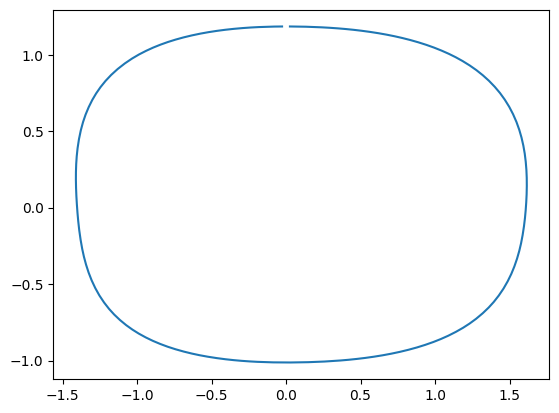

In [139]:
bc = get_ordered_body_coords(graph)
plt.plot(bc[:,0], bc[:,1])

In [140]:
from utils_potential import body_panels, sol_pot, mk_coeff_xy
from utils import get_ordered_body_coords
from plot_utils import plot_field
import pandas as pd

KeyboardInterrupt: 

In [ ]:
def get_potential_solution(graph):
    xycpan, xpan, ypan, thpan, nor = body_panels(get_ordered_body_coords(graph).numpy()) # (N,2)
    sigma_x, sigma_y = sol_pot(xycpan, xpan, ypan, thpan, nor)
    Ax_field, Ay_field = mk_coeff_xy(graph.pos[graph.node_type_one_hot[:,0]==0].numpy(), thpan, xpan, ypan)
    u_pot_field = np.matmul(Ax_field, sigma_x) + np.matmul(Ax_field, 0*sigma_y) + 1
    u_pot_field = torch.from_numpy(u_pot_field).float()
    v_pot_field = np.matmul(Ay_field, sigma_x) + np.matmul(Ay_field, 0*sigma_y) + 0
    v_pot_field = torch.from_numpy(v_pot_field).float()
    potential_solution = torch.zeros_like(graph.pos)
    potential_solution[graph.node_type_one_hot[:,0]==0] = torch.cat([u_pot_field, v_pot_field], dim=1)
    return potential_solution

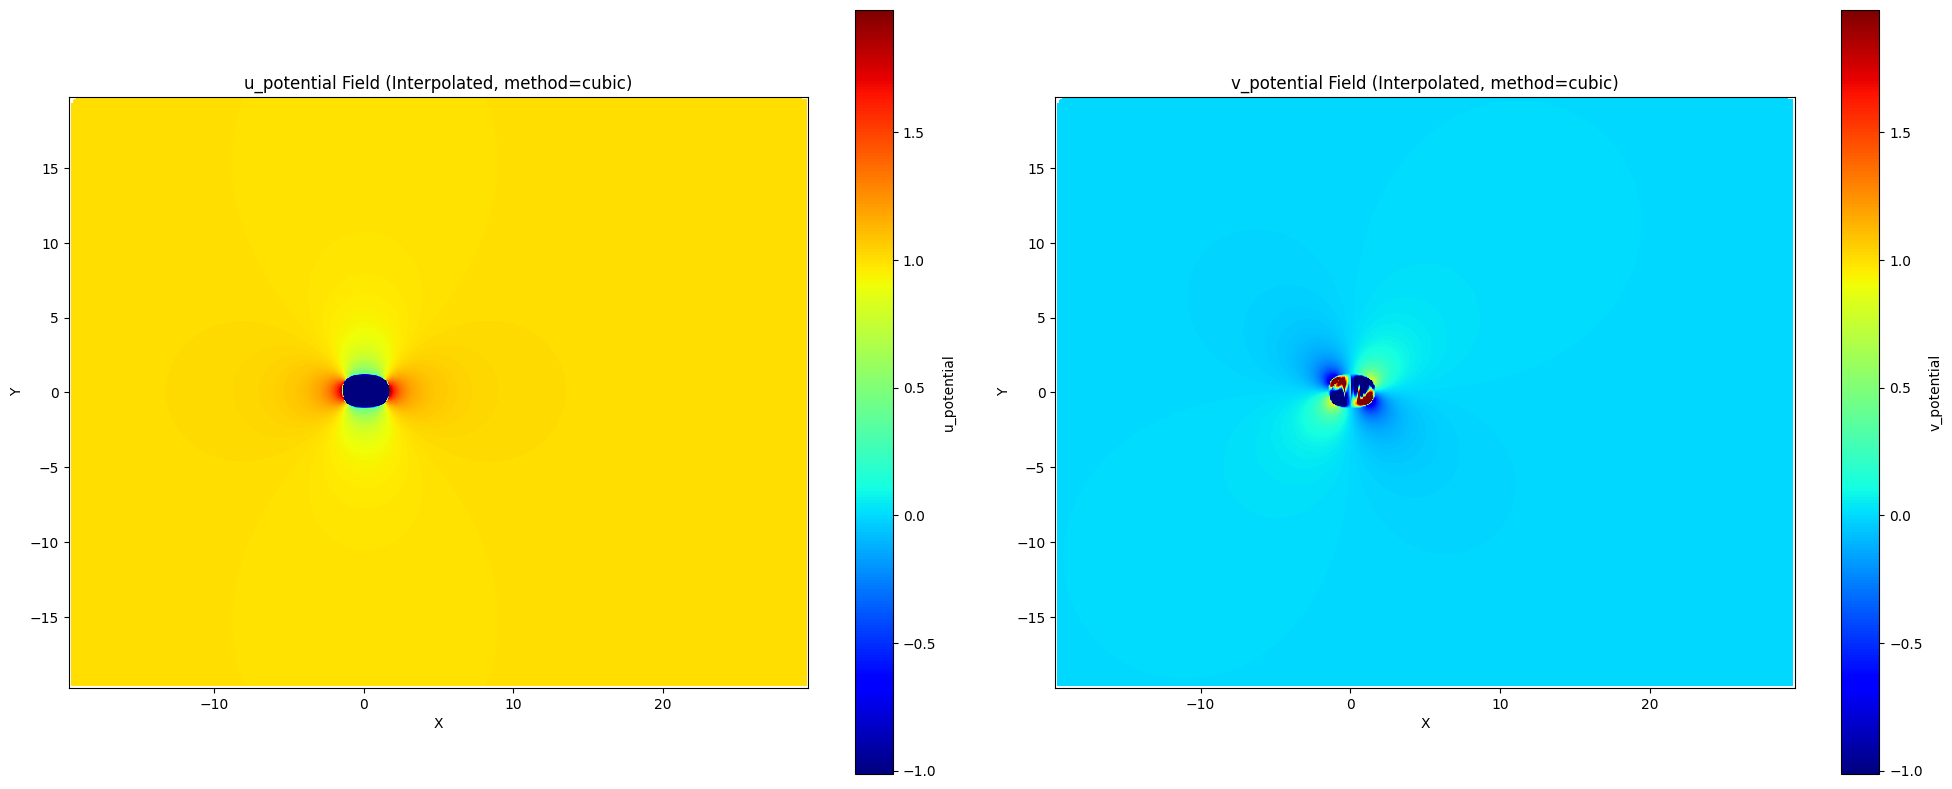

In [ ]:
graph.potential_solution = get_potential_solution(graph)

df = pd.DataFrame({'X': graph.pos[:,0], 'Y': graph.pos[:,1], 'u_potential': graph.potential_solution[:,0], 'v_potential': graph.potential_solution[:,1] })
plot_field(df, variable=['u_potential', 'v_potential'], grid_resolution=500)

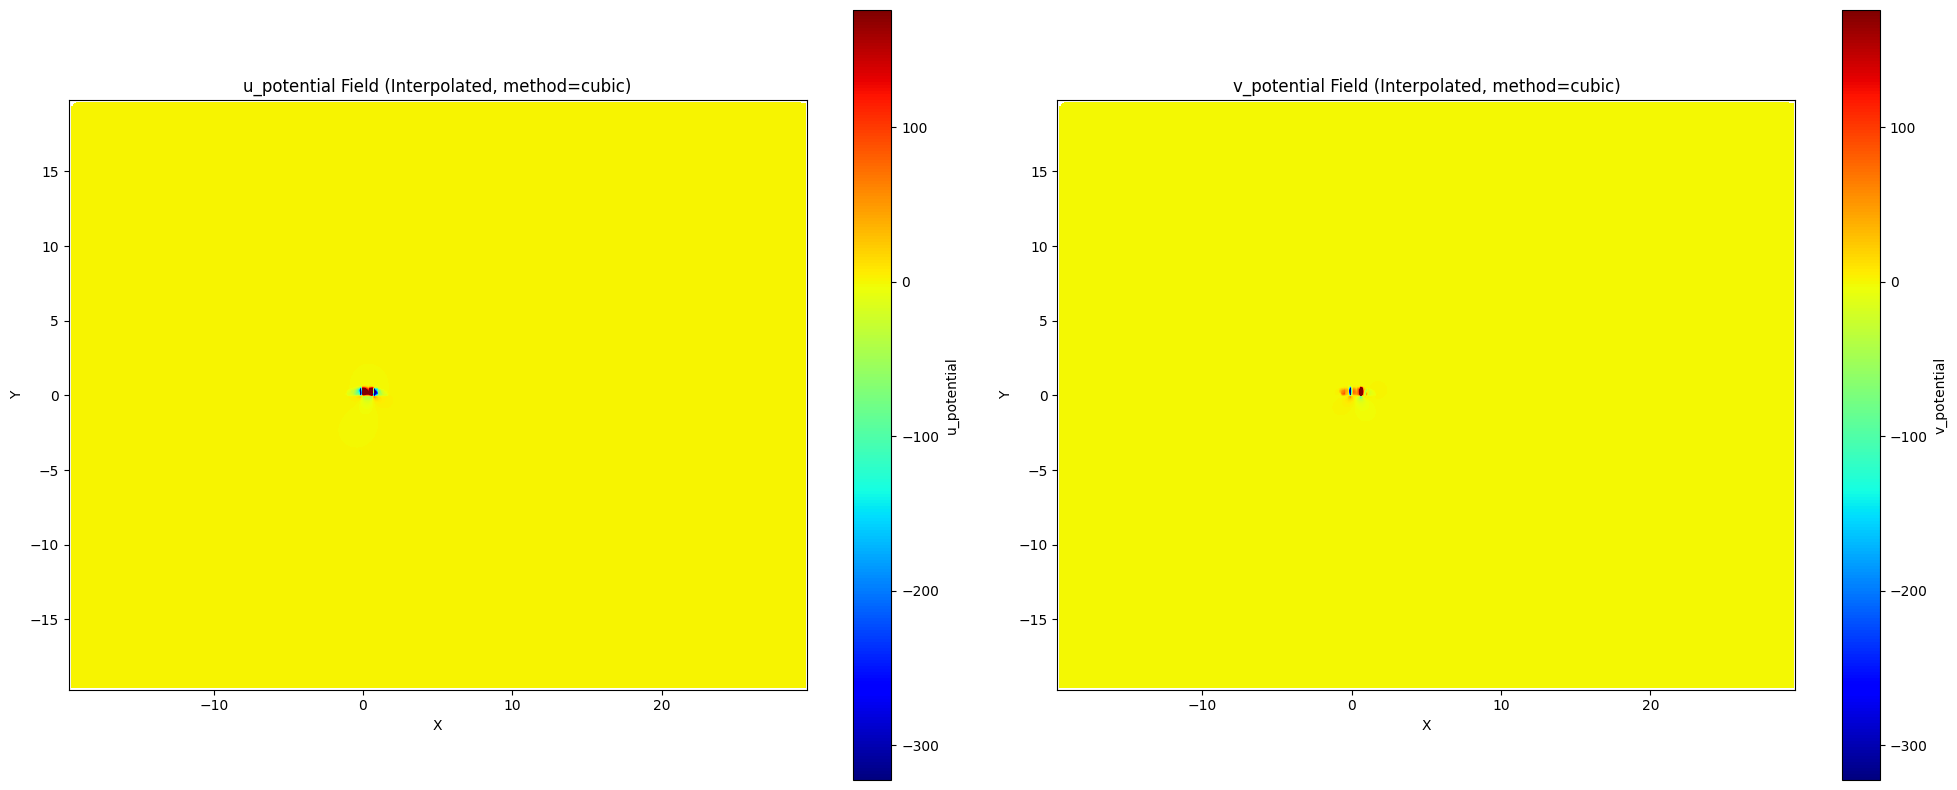

In [ ]:
geom_idx = 122
graph = torch.load(f'/davinci-1/work/dsalvatore/CFD/meshgraphnet_cubotto/data/train/processed_old/DSE-DACE500_workdir{geom_idx}.pt', weights_only=False)
def extract_bspline_points(file_path):
    with open(file_path) as f:
        line = f.read().split()
    points = [float(p) for p in line]
    return torch.tensor(points) # west_x, east_x, north_y, south_y

graph.bspline_points = extract_bspline_points(f'./data/train/raw/DSE-DACE500/workdir.{geom_idx}/input.txt')

graph.potential_solution = get_potential_solution(graph)

df = pd.DataFrame({'X': graph.pos[:,0], 'Y': graph.pos[:,1], 'u_potential': graph.potential_solution[:,0], 'v_potential': graph.potential_solution[:,1] })
plot_field(df, variable=['u_potential', 'v_potential'], grid_resolution=500)

body_mask = graph.node_type_one_hot[:,0] == 1
pos_body = graph.pos[body_mask]
check = pos_body[:,1].min() > graph.bspline_points[-1] and pos_body[:,1].max() < graph.bspline_points[-2]
print('check', check)

plt.scatter(pos_body[:,0], pos_body[:,1])
plt.show()

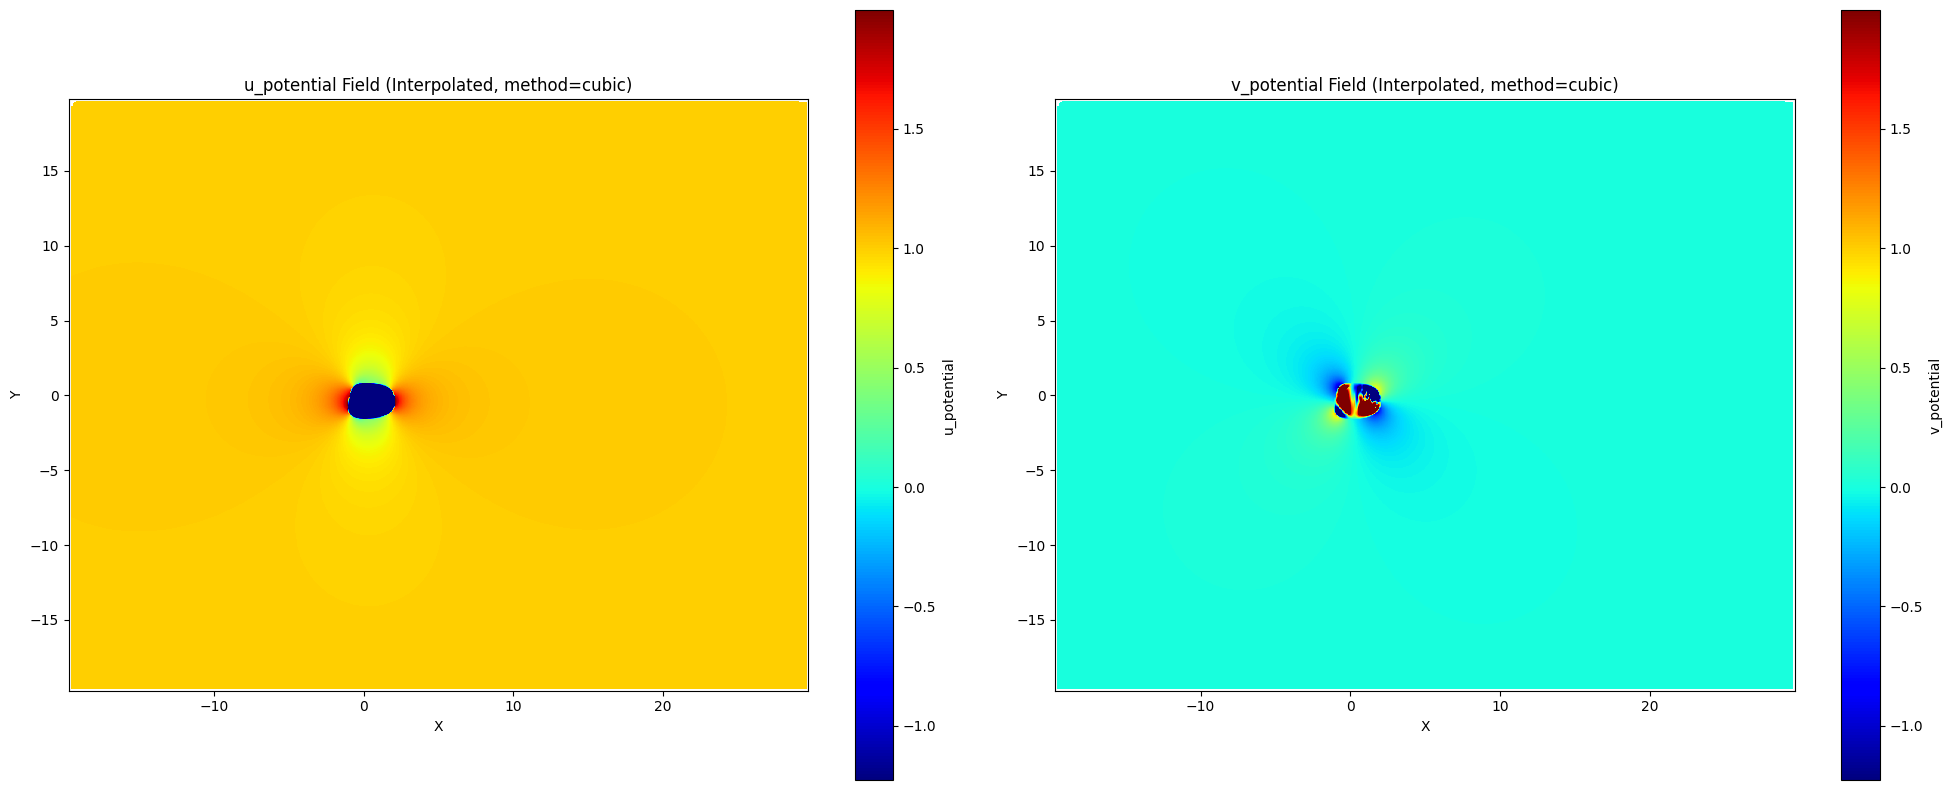

check tensor(False)


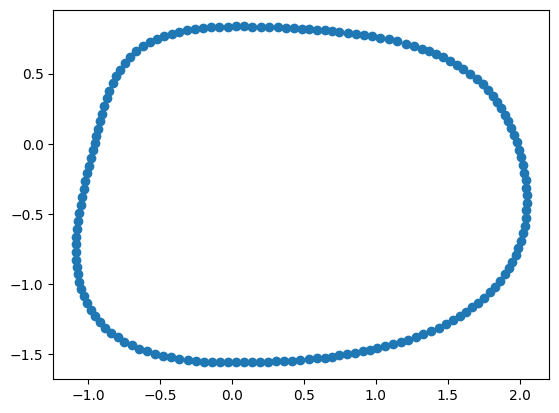

In [ ]:
geom_idx = 121
graph = torch.load(f'/davinci-1/work/dsalvatore/CFD/meshgraphnet_cubotto/data/train/processed_old/DSE-DACE500_workdir{geom_idx}.pt', weights_only=False)
def extract_bspline_points(file_path):
    with open(file_path) as f:
        line = f.read().split()
    points = [float(p) for p in line]
    return torch.tensor(points) # west_x, east_x, north_y, south_y

graph.bspline_points = extract_bspline_points(f'./data/train/raw/DSE-DACE500/workdir.{geom_idx}/input.txt')

graph.potential_solution = get_potential_solution(graph)

df = pd.DataFrame({'X': graph.pos[:,0], 'Y': graph.pos[:,1], 'u_potential': graph.potential_solution[:,0], 'v_potential': graph.potential_solution[:,1] })
plot_field(df, variable=['u_potential', 'v_potential'], grid_resolution=500)

body_mask = graph.node_type_one_hot[:,0] == 1
pos_body = graph.pos[body_mask]
check = pos_body[:,1].min() > graph.bspline_points[-1] and pos_body[:,1].max() < graph.bspline_points[-2]
print('check', check)

plt.scatter(pos_body[:,0], pos_body[:,1])
plt.show()

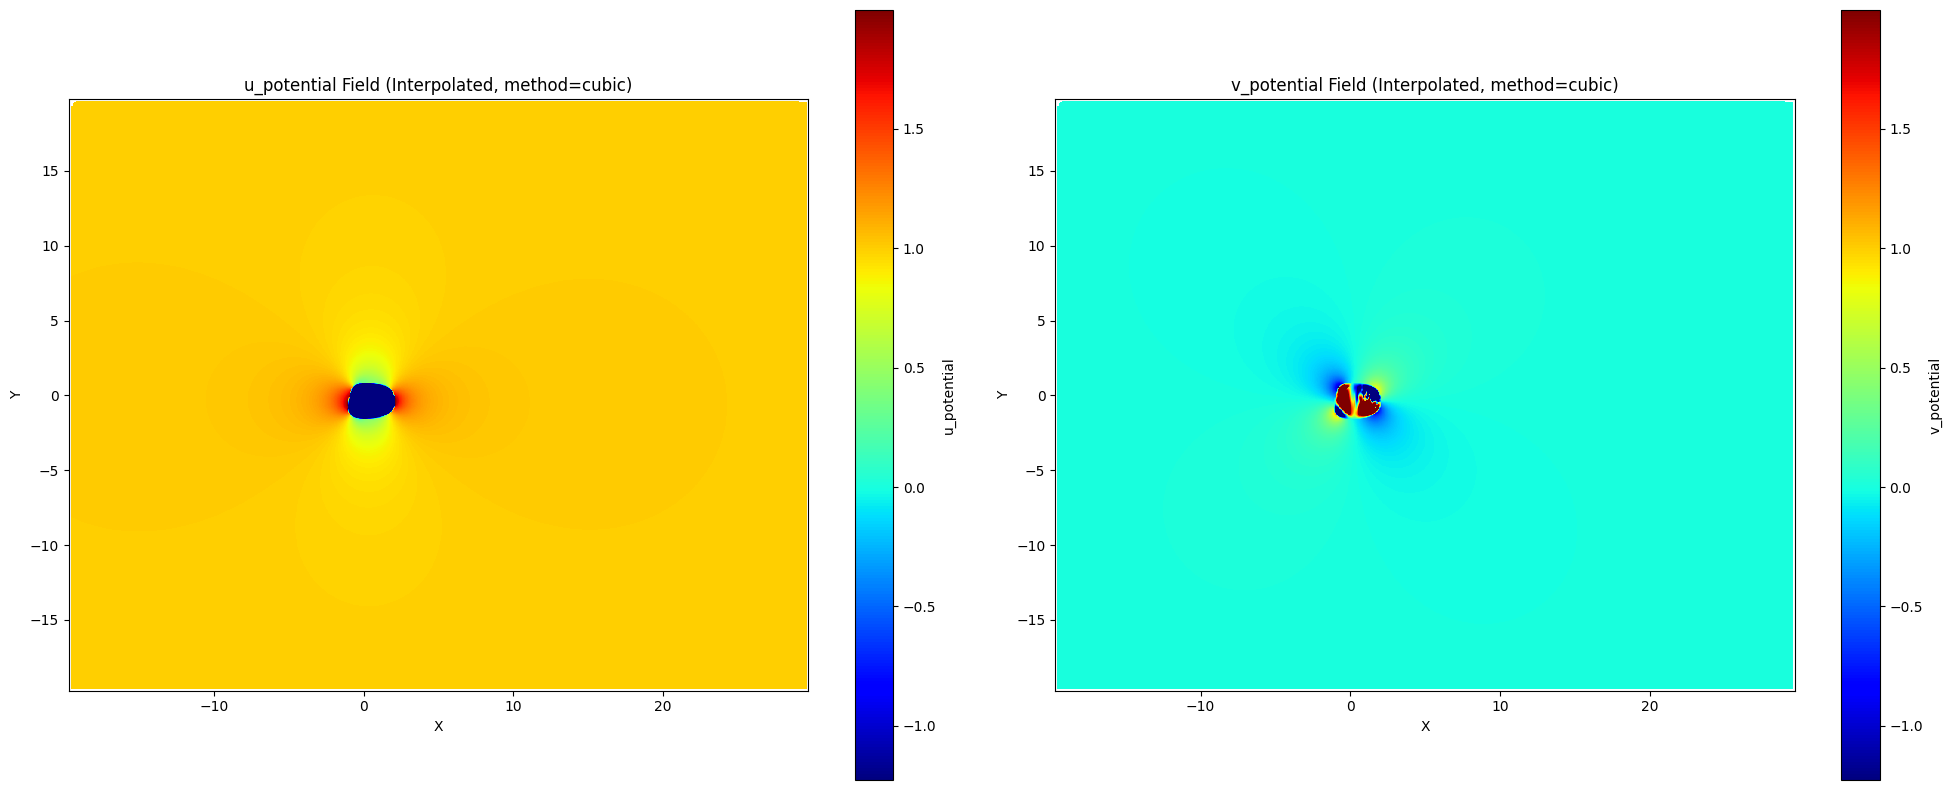

check tensor(False)


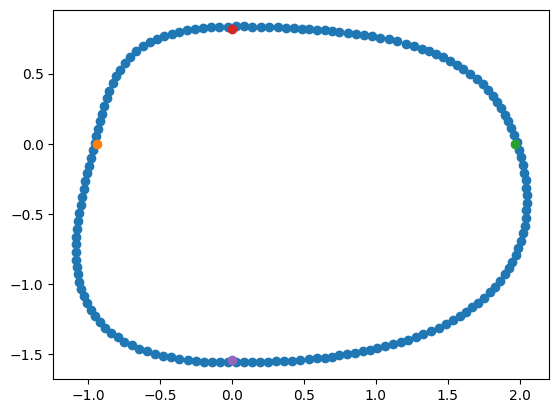

In [ ]:
geom_idx = 121
graph = torch.load(f'/davinci-1/work/dsalvatore/CFD/meshgraphnet_cubotto/data/train/processed_old/DSE-DACE500_workdir{geom_idx}.pt', weights_only=False)
def extract_bspline_points(file_path):
    with open(file_path) as f:
        line = f.read().split()
    points = [float(p) for p in line]
    return torch.tensor(points) # west_x, east_x, north_y, south_y

graph.bspline_points = extract_bspline_points(f'./data/train/raw/DSE-DACE500/workdir.{geom_idx}/input.txt')

graph.potential_solution = get_potential_solution(graph)

df = pd.DataFrame({'X': graph.pos[:,0], 'Y': graph.pos[:,1], 'u_potential': graph.potential_solution[:,0], 'v_potential': graph.potential_solution[:,1] })
plot_field(df, variable=['u_potential', 'v_potential'], grid_resolution=500)

body_mask = graph.node_type_one_hot[:,0] == 1
pos_body = graph.pos[body_mask]
check = pos_body[:,1].min() > graph.bspline_points[-1] and pos_body[:,1].max() < graph.bspline_points[-2]
print('check', check)

plt.scatter(pos_body[:,0], pos_body[:,1])
plt.scatter(graph.bspline_points[0], 0)
plt.scatter(graph.bspline_points[1], 0)
plt.scatter(0, graph.bspline_points[2])
plt.scatter(0, graph.bspline_points[3])
plt.scatter

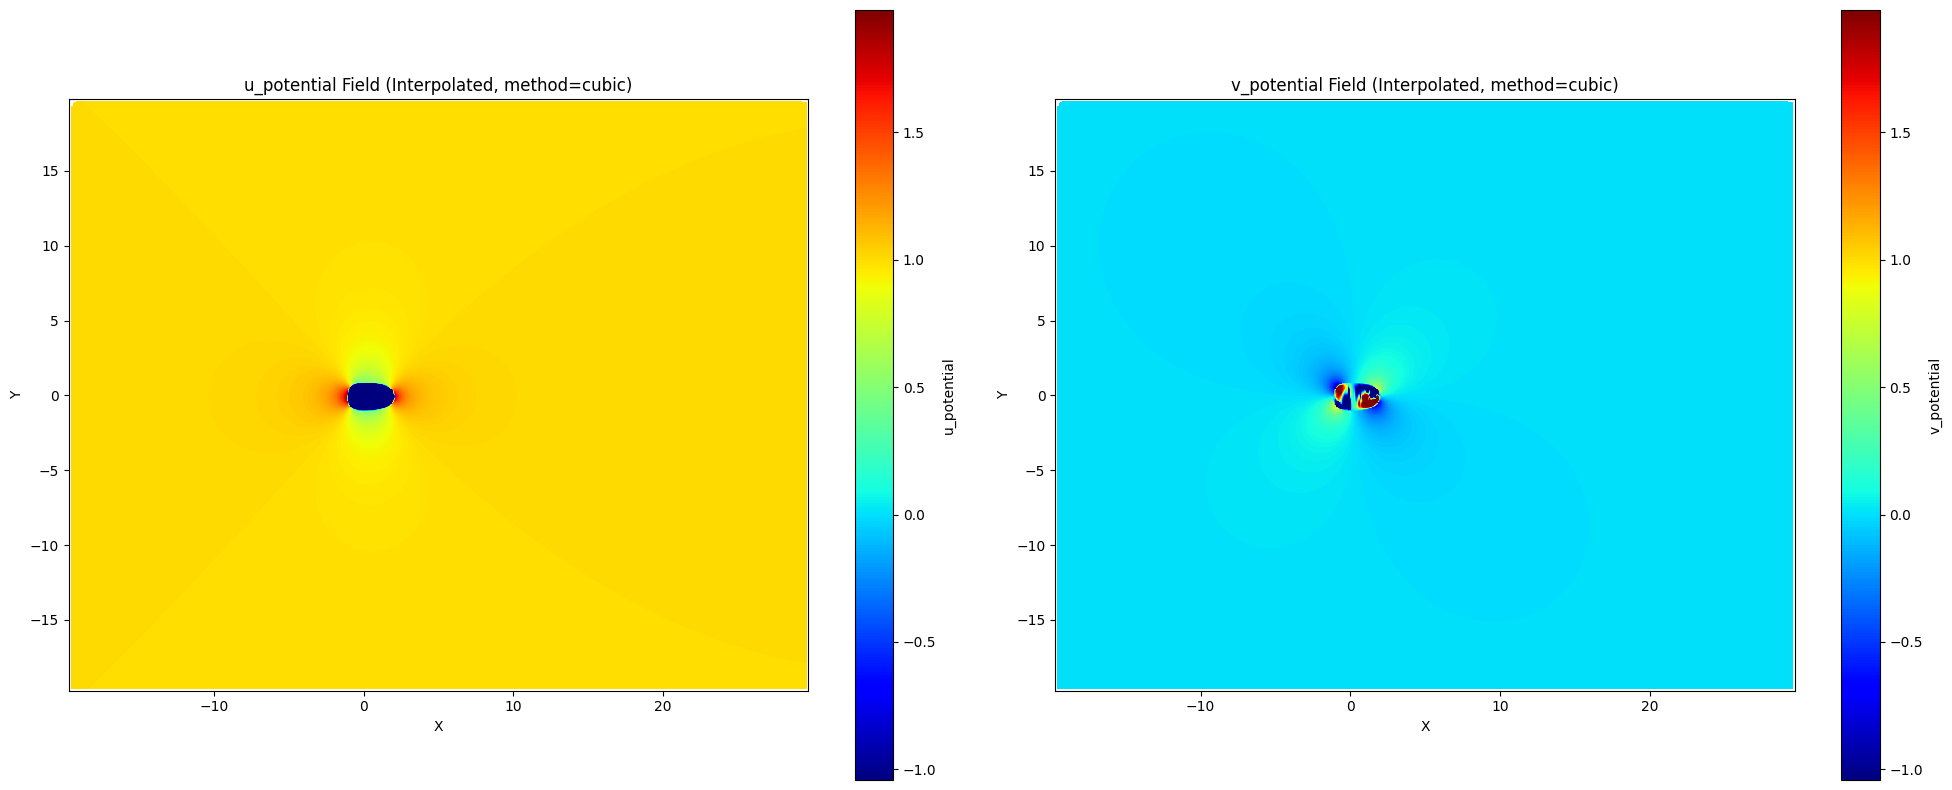

check tensor(True)


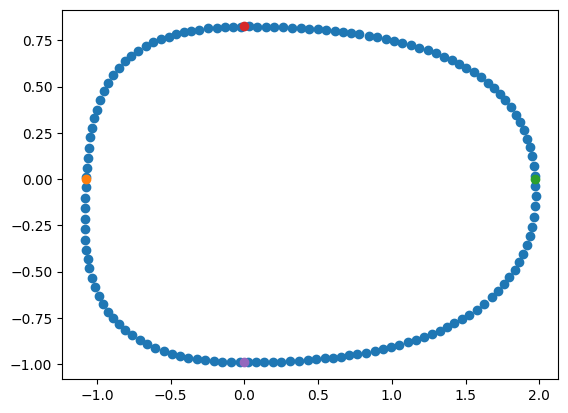

In [ ]:
geom_idx = 489
graph = torch.load(f'/davinci-1/work/dsalvatore/CFD/meshgraphnet_cubotto/data/train/processed_old/DSE-DACE500_workdir{geom_idx}.pt', weights_only=False)
def extract_bspline_points(file_path):
    with open(file_path) as f:
        line = f.read().split()
    points = [float(p) for p in line]
    return torch.tensor(points) # west_x, east_x, north_y, south_y

graph.bspline_points = extract_bspline_points(f'./data/train/raw/DSE-DACE500/workdir.{geom_idx}/input.txt')

graph.potential_solution = get_potential_solution(graph)

df = pd.DataFrame({'X': graph.pos[:,0], 'Y': graph.pos[:,1], 'u_potential': graph.potential_solution[:,0], 'v_potential': graph.potential_solution[:,1] })
plot_field(df, variable=['u_potential', 'v_potential'], grid_resolution=500)

with open(f'./data/train/raw/DSE-DACE500/workdir.{geom_idx}/1000/C', 'r') as f:
    lines = f.read().splitlines()
prof_extruded_line = lines.index('    prof_extruded')
n = int(lines[prof_extruded_line + 4])
body_pos = torch.tensor([[float(c) for c in line[1:-1].split()[:2]] for line in lines[prof_extruded_line+6 : prof_extruded_line+6+n]])
check = pos_body[:,1].min() - graph.bspline_points[-1] > -0.05 and pos_body[:,1].max() - graph.bspline_points[-2] < 0.05
print('check', check)

plt.scatter(body_pos[:,0], body_pos[:,1])
plt.scatter(graph.bspline_points[0], 0)
plt.scatter(graph.bspline_points[1], 0)
plt.scatter(0, graph.bspline_points[2])
plt.scatter(0, graph.bspline_points[3])

In [ ]:
with open(f'./data/test/raw/DSE-DACE100/workdir.{geom_idx}/1000/C', 'r') as f:
    lines = f.read().splitlines()
prof_extruded_line = lines.index('    prof_extruded')
n = int(lines[prof_extruded_line + 4])
body = [[float(c) for c in line[1:-1].split()[:2]] for line in lines[prof_extruded_line+6 : prof_extruded_line+6+n]]
body[0]

[-0.02826356103, -1.526412723]

In [ ]:
from define_dataset import MyOwnDataset
import yaml
folder = 'experiment1'
with open(f'./{folder}/config.yaml', 'r') as f:
    metadata = yaml.safe_load(f)
metadata['experiment_folder'] = folder
dataset = MyOwnDataset(metadata, split='test')

In [ ]:
import pickle
with open('./data/train/processed/filenames.pkl', 'rb') as f:
    filenames = pickle.load(f)
filenames

['DSE-DACE200_workdir1.pt',
 'DSE-DACE200_workdir2.pt',
 'DSE-DACE200_workdir4.pt',
 'DSE-DACE200_workdir5.pt',
 'DSE-DACE200_workdir6.pt',
 'DSE-DACE200_workdir7.pt',
 'DSE-DACE200_workdir8.pt',
 'DSE-DACE200_workdir9.pt',
 'DSE-DACE200_workdir10.pt',
 'DSE-DACE200_workdir11.pt',
 'DSE-DACE200_workdir12.pt',
 'DSE-DACE200_workdir13.pt',
 'DSE-DACE200_workdir16.pt',
 'DSE-DACE200_workdir17.pt',
 'DSE-DACE200_workdir18.pt',
 'DSE-DACE200_workdir19.pt',
 'DSE-DACE200_workdir20.pt',
 'DSE-DACE200_workdir21.pt',
 'DSE-DACE200_workdir22.pt',
 'DSE-DACE200_workdir23.pt',
 'DSE-DACE200_workdir24.pt',
 'DSE-DACE200_workdir26.pt',
 'DSE-DACE200_workdir27.pt',
 'DSE-DACE200_workdir28.pt',
 'DSE-DACE200_workdir29.pt',
 'DSE-DACE200_workdir30.pt',
 'DSE-DACE200_workdir31.pt',
 'DSE-DACE200_workdir32.pt',
 'DSE-DACE200_workdir33.pt',
 'DSE-DACE200_workdir34.pt',
 'DSE-DACE200_workdir35.pt',
 'DSE-DACE200_workdir36.pt',
 'DSE-DACE200_workdir37.pt',
 'DSE-DACE200_workdir38.pt',
 'DSE-DACE200_workdir3

In [ ]:
import torch
mean = torch.load('./data/train/processed/mean_N[200, 500].pt')
std = torch.load('./data/train/processed/std_N[200, 500].pt')

mean, std

({'distance_vector': tensor([-6.0205e-12, -7.8297e-12]),
  'distance_magnitude': tensor([0.3604]),
  'velocity': tensor([ 8.2920e-01, -3.3381e-04]),
  'velocity_mean': tensor([ 8.3418e-01, -2.6783e-04]),
  'pressure': tensor([-0.0458]),
  'pressure_mean': tensor([-0.0470]),
  'distance_from_obj_vec': tensor([2.7842, 0.3858]),
  'distance_from_obj_mag': tensor([11.0452]),
  'potential_solution': tensor([9.8256e-01, 1.8777e-04])},
 {'distance_vector': tensor([0.3112, 0.3006]),
  'distance_magnitude': tensor([0.2393]),
  'velocity': tensor([0.3756, 0.1511]),
  'velocity_mean': tensor([0.3682, 0.1492]),
  'pressure': tensor([0.1597]),
  'pressure_mean': tensor([0.1624]),
  'distance_from_obj_vec': tensor([11.1705,  8.9104]),
  'distance_from_obj_mag': tensor([9.4910]),
  'potential_solution': tensor([0.3135, 0.2840])})

# Extract graph

## Topology

### Owner

In [ ]:
file = './data/DSE-DACE200/workdir.1/constant/polyMesh/owner'

with open(file, 'r') as f:
    lines = f.read().splitlines()
lines

['/*--------------------------------*- C++ -*----------------------------------*\\',
 '  =========                 |',
 '  \\\\      /  F ield         | OpenFOAM: The Open Source CFD Toolbox',
 '   \\\\    /   O peration     | Website:  https://openfoam.org',
 '    \\\\  /    A nd           | Version:  12',
 '     \\\\/     M anipulation  |',
 '\\*---------------------------------------------------------------------------*/',
 'FoamFile',
 '{',
 '    format      ascii;',
 '    class       labelList;',
 '    note        "nPoints: 9026 nCells: 8702 nFaces: 30619 nInternalFaces: 12891";',
 '    location    "constant/polyMesh";',
 '    object      owner;',
 '}',
 '// * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * //',
 '',
 '',
 '30619',
 '(',
 '0',
 '1',
 '1',
 '2',
 '2',
 '3',
 '4',
 '4',
 '5',
 '6',
 '6',
 '7',
 '8',
 '8',
 '9',
 '10',
 '10',
 '11',
 '12',
 '12',
 '13',
 '14',
 '14',
 '15',
 '16',
 '16',
 '17',
 '18',
 '18',
 '19',
 '20',
 '20',
 '21',
 '22',


In [ ]:
lines[18], lines[20], lines[21], int(lines[20]), lines[-1], lines[20+int(lines[18])-1], lines[20+int(lines[18])]

('30619',
 '0',
 '1',
 0,
 '// ************************************************************************* //',
 '8701',
 ')')

In [ ]:
with open(file, 'r') as f:
    lines = f.read().splitlines()

n_owners = int(lines[18])
owners = torch.tensor([int(o) for o in lines[20:20+n_owners]])

In [ ]:
[(owners==idx).sum() for idx in [10,123, 124, 7333]], len(owners)

([tensor(5), tensor(3), tensor(5), tensor(3)], 30619)

### Neighbours

In [ ]:
file = './data/DSE-DACE200/workdir.1/constant/polyMesh/neighbour'

with open(file, 'r') as f:
    lines = f.read().splitlines()
lines

['/*--------------------------------*- C++ -*----------------------------------*\\',
 '  =========                 |',
 '  \\\\      /  F ield         | OpenFOAM: The Open Source CFD Toolbox',
 '   \\\\    /   O peration     | Website:  https://openfoam.org',
 '    \\\\  /    A nd           | Version:  12',
 '     \\\\/     M anipulation  |',
 '\\*---------------------------------------------------------------------------*/',
 'FoamFile',
 '{',
 '    format      ascii;',
 '    class       labelList;',
 '    note        "nPoints: 9026 nCells: 8702 nFaces: 30619 nInternalFaces: 12891";',
 '    location    "constant/polyMesh";',
 '    object      neighbour;',
 '}',
 '// * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * //',
 '',
 '',
 '12891',
 '(',
 '424',
 '3',
 '639',
 '3',
 '5',
 '963',
 '5',
 '7',
 '641',
 '7',
 '9',
 '642',
 '9',
 '11',
 '644',
 '11',
 '13',
 '646',
 '13',
 '15',
 '648',
 '15',
 '17',
 '650',
 '17',
 '19',
 '652',
 '19',
 '21',
 '654',
 '21',

In [ ]:
lines[18], lines[19], lines[20], lines[21], int(lines[20]), lines[-1], lines[20+int(lines[18])-1], lines[20+int(lines[18])]

('12891',
 '(',
 '424',
 '3',
 424,
 '// ************************************************************************* //',
 '8699',
 ')')

In [ ]:
with open(file, 'r') as f:
    lines = f.read().splitlines()

n_neigh = int(lines[18])
neigh = torch.tensor([int(o) for o in lines[20:20+n_neigh]])

In [ ]:
neigh.unique().shape

torch.Size([8377])

### Edge_index

In [ ]:
edge_index = torch.stack([neigh, owners[:len(neigh)]])
edge_index = torch.cat([edge_index, edge_index.flip(dims=[0])], dim=1)
edge_index

tensor([[ 424,    3,  639,  ..., 8694, 8694, 8697],
        [   0,    1,    1,  ..., 8695, 8696, 8699]])

In [ ]:
a = torch.arange(10).reshape((2,5))
a, a.flip(dims=[0])

(tensor([[0, 1, 2, 3, 4],
         [5, 6, 7, 8, 9]]),
 tensor([[5, 6, 7, 8, 9],
         [0, 1, 2, 3, 4]]))

## Centers

In [ ]:
file = './data/DSE-DACE200/workdir.1/1000/C'
with open(file, 'r') as f:
    lines = f.read().splitlines()
lines

['/*--------------------------------*- C++ -*----------------------------------*\\',
 '  =========                 |',
 '  \\\\      /  F ield         | OpenFOAM: The Open Source CFD Toolbox',
 '   \\\\    /   O peration     | Website:  https://openfoam.org',
 '    \\\\  /    A nd           | Version:  12',
 '     \\\\/     M anipulation  |',
 '\\*---------------------------------------------------------------------------*/',
 'FoamFile',
 '{',
 '    format      ascii;',
 '    class       volVectorField;',
 '    location    "1000";',
 '    object      C;',
 '}',
 '// * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * //',
 '',
 'dimensions      [0 1 0 0 0 0 0];',
 '',
 'internalField   nonuniform List<vector> ',
 '8702',
 '(',
 '(-19.66666667 -19.66666667 0.5)',
 '(-19.71584619 -18.45156643 0.5)',
 '(-19.69488513 -17.48741301 0.5)',
 '(-19.41073132 -17.93897944 0.5)',
 '(-19.70017645 -16.49312349 0.5)',
 '(-19.39506158 -16.9805365 0.5)',
 '(-19.70566807 -15.49504

In [ ]:
# to extract all of them
pattern = r"^\((\s*-?\d+(\.\d*)?)\s+(-?\d+(\.\d*)?)\s+(-?\d+(\.\d*)?)\)$"
positions = []
for line in lines:
    if re.match(pattern, line):
        positions.append([float(p) for p in line[1:-1].split()[:2]])  # discard the 3rd as it is the z variable


In [ ]:
len(positions), positions[-1]

(9016, [30.0, 18.5])

In [ ]:
lines[19], lines[21],  lines[21][1:-1], lines

('8702',
 '(-19.66666667 -19.66666667 0.5)',
 '-19.66666667 -19.66666667 0.5',
 ['/*--------------------------------*- C++ -*----------------------------------*\\',
  '  =========                 |',
  '  \\\\      /  F ield         | OpenFOAM: The Open Source CFD Toolbox',
  '   \\\\    /   O peration     | Website:  https://openfoam.org',
  '    \\\\  /    A nd           | Version:  12',
  '     \\\\/     M anipulation  |',
  '\\*---------------------------------------------------------------------------*/',
  'FoamFile',
  '{',
  '    format      ascii;',
  '    class       volVectorField;',
  '    location    "1000";',
  '    object      C;',
  '}',
  '// * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * //',
  '',
  'dimensions      [0 1 0 0 0 0 0];',
  '',
  'internalField   nonuniform List<vector> ',
  '8702',
  '(',
  '(-19.66666667 -19.66666667 0.5)',
  '(-19.71584619 -18.45156643 0.5)',
  '(-19.69488513 -17.48741301 0.5)',
  '(-19.41073132 -17.93897944

In [ ]:
# I only need the internal fields one
n_centers = int(lines[19])
centers = torch.tensor([[float(c) for c in center[1:-1].split()[:2]] for center in lines[21:21+n_centers]])
centers.shape, centers

(torch.Size([8702, 2]),
 tensor([[-19.6667, -19.6667],
         [-19.7158, -18.4516],
         [-19.6949, -17.4874],
         ...,
         [  5.7667,   0.1637],
         [  9.4874,   0.6403],
         [  6.2616,  -1.4845]]))

## Points

In [ ]:
file = './data/DSE-DACE200/workdir.1/constant/polyMesh/points'
with open(file, 'r') as f:
    lines = f.read().splitlines()
lines

['/*--------------------------------*- C++ -*----------------------------------*\\',
 '  =========                 |',
 '  \\\\      /  F ield         | OpenFOAM: The Open Source CFD Toolbox',
 '   \\\\    /   O peration     | Website:  https://openfoam.org',
 '    \\\\  /    A nd           | Version:  12',
 '     \\\\/     M anipulation  |',
 '\\*---------------------------------------------------------------------------*/',
 'FoamFile',
 '{',
 '    format      ascii;',
 '    class       vectorField;',
 '    location    "constant/polyMesh";',
 '    object      points;',
 '}',
 '// * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * //',
 '',
 '',
 '9026',
 '(',
 '(0 0.9165078119 0)',
 '(0 -1.33313281 0)',
 '(30 20 0)',
 '(30 -20 0)',
 '(-20 20 0)',
 '(-20 -20 0)',
 '(-20 -19 0)',
 '(-20 -18 0)',
 '(-20 -17 0)',
 '(-20 -16 0)',
 '(-20 -15 0)',
 '(-20 -14 0)',
 '(-20 -13 0)',
 '(-20 -12 0)',
 '(-20 -11 0)',
 '(-20 -10 0)',
 '(-20 -9 0)',
 '(-20 -8 0)',
 '(-20 -7 0)

In [ ]:
lines[17], lines[19]

('9026', '(0 0.9165078119 0)')

In [ ]:
n_points = int(lines[17])
points = [[float(p) for p in point[1:-1].split()] for point in lines[19:19+n_points]]
points[-1], len(points)

([5.277175431, -0.2831196961, 1.0], 9026)

## Faces

In [ ]:
file = './data/DSE-DACE200/workdir.1/constant/polyMesh/faces'
with open(file, 'r') as f:
    lines = f.read().splitlines()
lines

['/*--------------------------------*- C++ -*----------------------------------*\\',
 '  =========                 |',
 '  \\\\      /  F ield         | OpenFOAM: The Open Source CFD Toolbox',
 '   \\\\    /   O peration     | Website:  https://openfoam.org',
 '    \\\\  /    A nd           | Version:  12',
 '     \\\\/     M anipulation  |',
 '\\*---------------------------------------------------------------------------*/',
 'FoamFile',
 '{',
 '    format      ascii;',
 '    class       faceList;',
 '    location    "constant/polyMesh";',
 '    object      faces;',
 '}',
 '// * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * //',
 '',
 '',
 '30619',
 '(',
 '4(6 4513 4515 45)',
 '4(7 4516 4517 324)',
 '4(6 324 4517 4513)',
 '4(7 325 4519 4516)',
 '4(8 4518 4519 325)',
 '4(324 325 4519 4517)',
 '4(8 326 4521 4518)',
 '4(9 4520 4521 326)',
 '4(325 326 4521 4519)',
 '4(9 327 4523 4520)',
 '4(10 4522 4523 327)',
 '4(326 327 4523 4521)',
 '4(10 328 4525 4522)',
 '4(

In [ ]:
lines[17], lines[19], lines[19+int(lines[17])-1:]
n_faces = int(lines[17])
faces = [ [int(f) for f in face[2:-1].split()] for face in lines[19:19+n_faces]]

len(faces), faces[-5:]

(30619,
 [[7563, 9016, 7480],
  [4481, 4505, 4500],
  [9012, 8240, 8860],
  [4502, 4506, 4492],
  [8345, 9022, 7299]])

In [ ]:
faces[0]

[6, 4513, 4515, 45]

In [ ]:
faces_with_points = [[points[f] for f in face] for face in faces]
faces_with_points

[[[-20.0, -19.0, 0.0],
  [-20.0, -19.0, 1.0],
  [-19.0, -20.0, 1.0],
  [-19.0, -20.0, 0.0]],
 [[-20.0, -18.0, 0.0],
  [-20.0, -18.0, 1.0],
  [-19.14753858, -18.35469928, 1.0],
  [-19.14753858, -18.35469928, 0.0]],
 [[-20.0, -19.0, 0.0],
  [-19.14753858, -18.35469928, 0.0],
  [-19.14753858, -18.35469928, 1.0],
  [-20.0, -19.0, 1.0]],
 [[-20.0, -18.0, 0.0],
  [-19.08465538, -17.46223904, 0.0],
  [-19.08465538, -17.46223904, 1.0],
  [-20.0, -18.0, 1.0]],
 [[-20.0, -17.0, 0.0],
  [-20.0, -17.0, 1.0],
  [-19.08465538, -17.46223904, 1.0],
  [-19.08465538, -17.46223904, 0.0]],
 [[-19.14753858, -18.35469928, 0.0],
  [-19.08465538, -17.46223904, 0.0],
  [-19.08465538, -17.46223904, 1.0],
  [-19.14753858, -18.35469928, 1.0]],
 [[-20.0, -17.0, 0.0],
  [-19.10052936, -16.47937047, 0.0],
  [-19.10052936, -16.47937047, 1.0],
  [-20.0, -17.0, 1.0]],
 [[-20.0, -16.0, 0.0],
  [-20.0, -16.0, 1.0],
  [-19.10052936, -16.47937047, 1.0],
  [-19.10052936, -16.47937047, 0.0]],
 [[-19.08465538, -17.46223904, 0

In [ ]:
faces_with_points[0]

[[-20.0, -19.0, 0.0],
 [-20.0, -19.0, 1.0],
 [-19.0, -20.0, 1.0],
 [-19.0, -20.0, 0.0]]

In [ ]:
idx0 = torch.arange(len(owners))[owners==0]
faces0 = [faces_with_points[i] for i in idx0]
faces0

[[[-20.0, -19.0, 0.0],
  [-20.0, -19.0, 1.0],
  [-19.0, -20.0, 1.0],
  [-19.0, -20.0, 0.0]],
 [[-20.0, -20.0, 0.0],
  [-19.0, -20.0, 0.0],
  [-19.0, -20.0, 1.0],
  [-20.0, -20.0, 1.0]],
 [[-20.0, -19.0, 0.0],
  [-20.0, -20.0, 0.0],
  [-20.0, -20.0, 1.0],
  [-20.0, -19.0, 1.0]],
 [[-20.0, -19.0, 0.0], [-19.0, -20.0, 0.0], [-20.0, -20.0, 0.0]],
 [[-20.0, -19.0, 1.0], [-20.0, -20.0, 1.0], [-19.0, -20.0, 1.0]]]

In [ ]:
points_faces0 = torch.tensor([f for face in faces0 for f in face])
points_faces0.mean(dim=0)

tensor([-19.6667, -19.6667,   0.5000])

In [ ]:
idx0 = torch.arange(len(owners))[owners==1]
faces0 = [faces_with_points[i] for i in idx0]
faces0
points_faces0 = torch.tensor([f for face in faces0 for f in face])
points_faces0.mean(dim=0)

tensor([-19.7158, -18.4516,   0.5000])

## Node type

In [ ]:
file = './data/DSE-DACE200/workdir.1/constant/polyMesh/boundary'
with open(file, 'r') as f:
    lines = f.read()
lines

'/*--------------------------------*- C++ -*----------------------------------*\\\n  =========                 |\n  \\\\      /  F ield         | OpenFOAM: The Open Source CFD Toolbox\n   \\\\    /   O peration     | Website:  https://openfoam.org\n    \\\\  /    A nd           | Version:  12\n     \\\\/     M anipulation  |\n\\*---------------------------------------------------------------------------*/\nFoamFile\n{\n    format          ascii;\n    class           polyBoundaryMesh;\n    location        "constant/polyMesh";\n    object          boundary;\n}\n// * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * //\n\n\n5\n(\n    prof_extruded\n    {\n        type            patch;\n        nFaces          144;\n        startFace       12891;\n    }\n    free_extruded\n    {\n        type            patch;\n        nFaces          100;\n        startFace       13035;\n    }\n    in_extruded\n    {\n        type            patch;\n        nFaces          40;\n    

In [ ]:
patch_pattern = re.compile(
    r'(\w+)\s*\{\s*[^}]*?nFaces\s+(\d+);\s*startFace\s+(\d+);',
    re.MULTILINE | re.DOTALL
)

patches = {}
for match in patch_pattern.finditer(lines):
    patch_name = match.group(1)
    nFaces = int(match.group(2))
    startFace = int(match.group(3))
    patches[patch_name] = {
        'nFaces': nFaces,
        'startFace': startFace
    }

del patches['defaultFaces']
patches

{'prof_extruded': {'nFaces': 144, 'startFace': 12891},
 'free_extruded': {'nFaces': 100, 'startFace': 13035},
 'in_extruded': {'nFaces': 40, 'startFace': 13135},
 'out_extruded': {'nFaces': 40, 'startFace': 13175}}

In [ ]:
nodes_of_each_type = {key: owners[patches[key]['startFace']:patches[key]['startFace']+patches[key]['nFaces']] for key in patches.keys()}

In [ ]:
node_type_one_hot = torch.zeros(size=(len(owners.unique()), len(patches.keys())+1))

for i,key in enumerate(patches.keys()):
    node_type_one_hot[nodes_of_each_type[key],i] = 1

node_type_one_hot[node_type_one_hot.sum(axis=1)==0,-1] = 1

node_type_one_hot

tensor([[0., 1., 1., 0., 0.],
        [0., 0., 1., 0., 0.],
        [0., 0., 1., 0., 0.],
        ...,
        [0., 0., 0., 0., 1.],
        [0., 0., 0., 0., 1.],
        [0., 0., 0., 0., 1.]])

In [ ]:
sum(node_type_one_hot.sum(axis=1)==2)

tensor(3)

## Edge attributes

In [ ]:
distance_vector = centers[edge_index[0]] - centers[edge_index[1]]
distance_magnitude = torch.linalg.norm(distance_vector, dim=-1)
distance_vector, distance_magnitude

(tensor([[ 0.4625,  0.2925],
         [ 0.3051,  0.5126],
         [ 0.4625, -0.3741],
         ...,
         [ 0.4471, -0.3763],
         [-0.4283, -0.1311],
         [ 0.2192,  0.2205]]),
 tensor([0.5472, 0.5965, 0.5949,  ..., 0.5844, 0.4479, 0.3109]))

## U

In [ ]:
file = './data/DSE-DACE200/workdir.1/1000/U'
with open(file, 'r') as f:
    lines = f.read().splitlines()
lines

['/*--------------------------------*- C++ -*----------------------------------*\\',
 '  =========                 |',
 '  \\\\      /  F ield         | OpenFOAM: The Open Source CFD Toolbox',
 '   \\\\    /   O peration     | Website:  https://openfoam.org',
 '    \\\\  /    A nd           | Version:  12',
 '     \\\\/     M anipulation  |',
 '\\*---------------------------------------------------------------------------*/',
 'FoamFile',
 '{',
 '    format      ascii;',
 '    class       volVectorField;',
 '    location    "1000";',
 '    object      U;',
 '}',
 '// * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * //',
 '',
 'dimensions      [0 1 -1 0 0 0 0];',
 '',
 'internalField   nonuniform List<vector> ',
 '8702',
 '(',
 '(1.00000587 8.741495854e-06 0)',
 '(1.000013775 -8.028546933e-05 3.756355067e-19)',
 '(1.000011873 -0.0001588965919 0)',
 '(1.000070042 -0.000252858011 0)',
 '(1.000009145 -0.0002070539042 0)',
 '(1.00004641 -0.0003732154059 0)',
 '(1.00

In [ ]:
lines[19], lines[21]

('8702', '(1.00000587 8.741495854e-06 0)')

In [ ]:
n = int(lines[19])
out = torch.tensor([[float(l) for l in line[1:-1].split()[:2]] for line in lines[21:21+n]])
out

[[1.00000587, 8.741495854e-06],
 [1.000013775, -8.028546933e-05],
 [1.000011873, -0.0001588965919],
 [1.000070042, -0.000252858011],
 [1.000009145, -0.0002070539042],
 [1.00004641, -0.0003732154059],
 [1.000009211, -0.0002575133598],
 [1.000045869, -0.0004723412405],
 [1.000008041, -0.0003033730862],
 [1.000043622, -0.000571977262],
 [1.000007217, -0.0003463975263],
 [1.000039341, -0.000664865803],
 [1.000006085, -0.0003861519366],
 [1.000034707, -0.0007503663071],
 [1.000004299, -0.0004202851918],
 [1.000029546, -0.0008265044404],
 [1.000002392, -0.0004459075716],
 [1.00002281, -0.0008884450468],
 [1.000000512, -0.000461376265],
 [1.000014447, -0.0009315836007],
 [0.9999985098, -0.0004651952761],
 [1.000007555, -0.000953654325],
 [0.999996908, -0.0004564223372],
 [0.9999954063, -0.0009515233789],
 [0.9999949369, -0.0004341928673],
 [0.9999851734, -0.0009230393598],
 [0.9999929443, -0.0003981757024],
 [0.9999741152, -0.0008675863332],
 [0.9999910238, -0.0003485638135],
 [0.9999631572, 

## C

In [ ]:
file = './data/DSE-DACE200/workdir.1/1000/C'
with open(file, 'r') as f:
    lines = f.read().splitlines()
lines

['/*--------------------------------*- C++ -*----------------------------------*\\',
 '  =========                 |',
 '  \\\\      /  F ield         | OpenFOAM: The Open Source CFD Toolbox',
 '   \\\\    /   O peration     | Website:  https://openfoam.org',
 '    \\\\  /    A nd           | Version:  12',
 '     \\\\/     M anipulation  |',
 '\\*---------------------------------------------------------------------------*/',
 'FoamFile',
 '{',
 '    format      ascii;',
 '    class       volVectorField;',
 '    location    "1000";',
 '    object      C;',
 '}',
 '// * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * //',
 '',
 'dimensions      [0 1 0 0 0 0 0];',
 '',
 'internalField   nonuniform List<vector> ',
 '8702',
 '(',
 '(-19.66666667 -19.66666667 0.5)',
 '(-19.71584619 -18.45156643 0.5)',
 '(-19.69488513 -17.48741301 0.5)',
 '(-19.41073132 -17.93897944 0.5)',
 '(-19.70017645 -16.49312349 0.5)',
 '(-19.39506158 -16.9805365 0.5)',
 '(-19.70566807 -15.49504

In [ ]:
lines[19], lines[21]

('8702', '(-19.66666667 -19.66666667 0.5)')

## Pressure

In [ ]:
file = './data/DSE-DACE200/workdir.1/1000/p'
with open(file, 'r') as f:
    lines = f.read().splitlines()
lines

['/*--------------------------------*- C++ -*----------------------------------*\\',
 '  =========                 |',
 '  \\\\      /  F ield         | OpenFOAM: The Open Source CFD Toolbox',
 '   \\\\    /   O peration     | Website:  https://openfoam.org',
 '    \\\\  /    A nd           | Version:  12',
 '     \\\\/     M anipulation  |',
 '\\*---------------------------------------------------------------------------*/',
 'FoamFile',
 '{',
 '    format      ascii;',
 '    class       volScalarField;',
 '    location    "1000";',
 '    object      p;',
 '}',
 '// * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * //',
 '',
 'dimensions      [0 2 -2 0 0 0 0];',
 '',
 'internalField   nonuniform List<scalar> ',
 '8702',
 '(',
 '0.02055317821',
 '0.02078849208',
 '0.02117026547',
 '0.02091560245',
 '0.02176477783',
 '0.02140896286',
 '0.02254543241',
 '0.0220932753',
 '0.02350143077',
 '0.02296512476',
 '0.02462319087',
 '0.02400881748',
 '0.02589240002',
 '0.02

In [ ]:
lines[19], lines[21]

('8702', '0.02055317821')

In [ ]:
obj_center = (centers[node_type_one_hot[:,0]==1]).mean(dim=0, keepdim=True)
centers - obj_center

tensor([[-19.5787, -19.4509],
        [-19.6279, -18.2358],
        [-19.6069, -17.2716],
        ...,
        [  5.8547,   0.3795],
        [  9.5754,   0.8561],
        [  6.3495,  -1.2687]])

In [ ]:
os.getcwd()

'/davinci-1/work/dsalvatore/CFD/meshgraphnet_cubotto'

# C_L C_D

## $\frac{dU}{d\hat{n}}$

I need velocity vector $\vec{v}$, normal unit vector $\hat{n}$, tangent unit vector $\hat{t}$, and distance to body vector $\vec{d}$, then

\begin{equation}
\frac{dU}{d\hat{n}} = \frac{\vec{v} \cdot \hat{t}}{\vec{d} \cdot \hat{n}}
\end{equation}

In [4]:
def extract_polymesh(file_path: str):  #file path is ..../polyMesh
    """
    Extracts the data about the mesh which is found in the polymesh folder. 
    """
    def extract_topology():
        def extract(what: str, n_line: int, start_line: int, to_type):
            with open(os.path.join(file_path, what), 'r') as f:
                lines = f.read().splitlines()
            n = int(lines[n_line])
            return torch.tensor([to_type(l) for l in lines[start_line: start_line+n]])

        owners = extract('owner', 18, 20, int)
        neighbours = extract('neighbour', 18, 20, int)
    
        return owners, neighbours
    
    def parse_boundary():        
        with open(os.path.join(file_path, 'boundary'), 'r') as f:
            lines = f.read()
        patch_pattern = re.compile(
            r'(\w+)\s*\{\s*[^}]*?nFaces\s+(\d+);\s*startFace\s+(\d+);',
            re.MULTILINE | re.DOTALL
        )

        patches = {}
        for match in patch_pattern.finditer(lines):
            patch_name = match.group(1)
            nFaces = int(match.group(2))
            startFace = int(match.group(3))
            patches[patch_name] = {
                'nFaces': nFaces,
                'startFace': startFace
            }
        del patches['defaultFaces']
        return patches
        

    def extract_node_type(owners: torch.Tensor):

        patches = parse_boundary()
        # the types are in order prof, free, in, out
        nodes_of_each_type = {key: owners[patches[key]['startFace']:patches[key]['startFace']+patches[key]['nFaces']] 
                                for key in patches.keys()}

        node_type_one_hot = torch.zeros(size=(len(owners.unique()), len(patches.keys())+1))
        for i,key in enumerate(patches.keys()):
            node_type_one_hot[nodes_of_each_type[key],i] = 1

        node_type_one_hot[node_type_one_hot.sum(axis=1)==0,-1] = 1

        return node_type_one_hot
    
    def extract_body_faces():
        def order_segments_endpoints_(body_faces):
            """
            Orders the endpoints in place making up the "1d face" such that the first one
            comes first in clockwise order than the second.
            I need it to define the tangent and normal unequivocally
            """
            centroid = body_faces.mean(dim=(0,1))
            angles = torch.arctan2(body_faces[:,:,1]-centroid[1], body_faces[:,:,0]-centroid[0])
            prof_faces_flipped = body_faces.flip(dims=(1,))
            # I want angles[:,0] > angles[:,1] but treating differently the segment for which the atan is discontinuous 
            # mask = angles[:,0]<angles[:,1] & angles[:,0]*angles[:,1]>8 # I want to trat the segment whose endpoints have angles ~+pi and ~-pi separately
            mask = torch.logical_and(angles[:,0]<angles[:,1], angles[:,0]*angles[:,1]>-8)
            body_faces[mask] = prof_faces_flipped[mask]
            # angles[x,0] should be negative and angles[x,1] positive, so if not already the case, flip
            if angles[angles[:,0]*angles[:,1]<-8,0] > 0:
                body_faces[angles[:,0]*angles[:,1]<-8] = body_faces[angles[:,0]*angles[:,1]<-8]
            return body_faces
        patches = parse_boundary()
        # get idx of faces in file faces belonging to the object
        body_faces_idx = list(range(patches['prof_extruded']['startFace'],patches['prof_extruded']['startFace']+patches['prof_extruded']['nFaces']))
        # construct an Nx4 tensor of the indices of the 4 points making up each face
        body_faces_points_idx = torch.tensor([faces[i] for i in body_faces_idx])
        # construct an Nx4x3 tensor with the 3 coordinates (x,y,z) of the 4 verteces making up the N faces
        body_faces = points[body_faces_points_idx]
        # "project down" from 3 to 2 dims by getting rid of the 2 points "above"
        body_faces = body_faces[body_faces[:,:,-1]==0].reshape((len(body_faces_idx),2,3))
        # disregard the z value
        body_faces = body_faces[:,:,:2]
        order_segments_endpoints_(body_faces)
        return body_faces, body_faces_idx



    def extract_points():
        with open(os.path.join(file_path, 'points'), 'r') as f:
            lines = f.read().splitlines()
        n_points = int(lines[17])
        points = [[float(p) for p in point[1:-1].split()] for point in lines[19:19+n_points]]
        points = torch.tensor(points)
        return points
    

    def extract_faces():
        with open(os.path.join(file_path, 'faces'), 'r') as f:
            lines = f.read().splitlines()
        n_faces = int(lines[17])
        faces = [[int(f) for f in face[2:-1].split()] for face in lines[19:19+n_faces]]   # can't make it a tensor as some faces have 4 and other 3 points
        return faces  
        
    
    owners, neighbours = extract_topology()
    node_type_one_hot = extract_node_type(owners)
    points = extract_points()
    faces = extract_faces()
    body_faces, body_faces_idx = extract_body_faces()

    return owners, neighbours, points, faces, node_type_one_hot, body_faces, body_faces_idx


def make_edges(owners, neighbours, centers):
    edge_index = torch.stack([neighbours, owners[:len(neighbours)]])
    edge_index = torch.cat([edge_index, edge_index.flip(dims=[0])], dim=1)  # to undirected
    distance_vector = centers[edge_index[0]] - centers[edge_index[1]]
    distance_magnitude = torch.linalg.norm(distance_vector, dim=-1, keepdim=True)
    return edge_index, distance_vector, distance_magnitude


def get_distance_from_object(node_type_one_hot, centers):
    obj_center = (centers[node_type_one_hot[:,0]==1]).mean(dim=0)
    distance_vector = centers - obj_center
    distance_magnitude = torch.linalg.norm(distance_vector, dim=1, keepdim=True)
    return distance_vector, distance_magnitude


def extract_fields(file_path: str):   # file_path is .../1000
    """
    From the file of the final timestep, I will extract the fields (pressure and velocity) and their time average
    """
    def extract(what: str, n_line=19, start_line=21):
        with open(os.path.join(file_path, what), 'r') as f:
            lines = f.read().splitlines()
        n = int(lines[n_line])
        return torch.tensor([[float(l) for l in line[1:-1].split()[:2]] for line in lines[start_line:start_line+n]])
    
    def extract_pressure(which: str, n_line=19, start_line=21):
        with open(os.path.join(file_path, which), 'r') as f:
            lines = f.read().splitlines()
        n = int(lines[n_line])
        return torch.tensor([float(l) for l in lines[start_line: start_line+n]]).unsqueeze(-1)
    
    def extract_body_coords():
        with open(os.path.join(file_path, 'C'), 'r') as f:
            lines = f.read().splitlines()
        prof_extruded_line = lines.index('    prof_extruded')
        n = int(lines[prof_extruded_line + 4])
        return torch.tensor([[float(c) for c in line[1:-1].split()[:2]] for line in lines[prof_extruded_line+6 : prof_extruded_line+6+n]])
            

    velocity = extract('U')
    velocity_mean = extract('UMean')
    centers = extract('C')
    pressure = extract_pressure('p')
    pressure_mean = extract_pressure('pMean')
    body_coords = extract_body_coords()

    return velocity, velocity_mean, pressure, pressure_mean, centers, body_coords


def extract_bspline_points(file_path):
    with open(file_path) as f:
        line = f.read().split()
    points = [float(p) for p in line]
    return torch.tensor(points) # west_x, east_x, north_y, south_y


def check_orderability(graph):
    """"
    Checks that the nodes on the object are easily orderable (i.e. the tips are not higher or lower than the center)
    """
    check = graph.body_coords[:,1].min() >= graph.bspline_points[-1] and graph.body_coords[:,1].max() <= graph.bspline_points[-2]
    return check


def extract_graph(N: int, i: int):
    """
    Extracts the data from the OPENFoam output and makes it into a graph.
    Since the simulation is finite volume, I will construct and use the graph which connects the cell centers (of adjecent cells),
    not the mesh that has as edges the edge of the cell 
    """
    owners, neighbours, points, faces, node_type_one_hot, body_faces, body_faces_idx = extract_polymesh(os.path.join(self.raw_dir, f'DSE-DACE{N}/workdir.{i}/constant/polyMesh'))
    velocity, velocity_mean, pressure, pressure_mean, centers, body_coords = extract_fields(os.path.join(self.raw_dir, f'DSE-DACE{N}/workdir.{i}/1000'))
    bspline_points = extract_bspline_points(os.path.join(self.raw_dir, f'DSE-DACE{N}/workdir.{i}/input.txt'))
    edge_index, distance_vector, distance_magnitude = make_edges(owners, neighbours, centers)
    distance_from_obj_vec, distance_from_obj_mag = get_distance_from_object(node_type_one_hot, centers)

## Gradient

In [12]:
file_path = f'./data/test/raw/DSE-DACE100/workdir.100'
owners, neighbours, points, faces, node_type_one_hot, body_faces, body_faces_idx = extract_polymesh(os.path.join(file_path,'constant/polyMesh' ))
velocity, velocity_mean, pressure, pressure_mean, centers, body_coords = extract_fields(os.path.join(file_path, '1000'))

In [93]:
# make all faces triangular with nans if 4 since I won't use them
mask = torch.tensor([len(face)==3 for face in faces])
owners_ = owners[mask]
faces_ = torch.tensor([face for face in faces if len(face)==3])
owners_.size(0), faces_.size(0), owners_, faces_

(16370,
 16370,
 tensor([   0,    0,    1,  ..., 8183, 8184, 8184]),
 tensor([[   6,   45,    5],
         [4239, 4240, 4241],
         [   7,  293,    6],
         ...,
         [8469, 6248, 6188],
         [4216, 4224, 4227],
         [8469, 6188, 7092]]))

In [94]:
owners_.size(0) / owners_.unique().size(0)

2.0

In [97]:
owners_

tensor([   0,    0,    1,  ..., 8183, 8184, 8184])

In [102]:
faces_[torch.where(owners_==0)[0]]

tensor([[   6,   45,    5],
        [4239, 4240, 4241]])

In [121]:
owners_.shape, faces_, owners_.unsqueeze(1).repeat((1,3)).shape

(torch.Size([16370]),
 tensor([[   6,   45,    5],
         [4239, 4240, 4241],
         [   7,  293,    6],
         ...,
         [8469, 6248, 6188],
         [4216, 4224, 4227],
         [8469, 6188, 7092]]),
 torch.Size([16370, 3]))

In [130]:
owners_, faces_

(tensor([   0,    0,    1,  ..., 8183, 8184, 8184]),
 tensor([[   6,   45,    5],
         [4239, 4240, 4241],
         [   7,  293,    6],
         ...,
         [8469, 6248, 6188],
         [4216, 4224, 4227],
         [8469, 6188, 7092]]))

In [143]:
torch.tensor([torch.tensor([1,2,3]), torch.tensor([1,2,3])])

TypeError: only integer tensors of a single element can be converted to an index

In [146]:
torch.stack(faces_of_cell_i).shape

torch.Size([8185, 2, 3])

In [148]:
faces_of_cell_i = torch.stack([faces_[torch.where(owners_==i)[0]] for i in range(owners_.max()+1)])

points_of_cell_i = points[faces_of_cell_i]

points_of_cell_i.shape

torch.Size([8185, 2, 3, 3])

In [ ]:
face_of_cell_i = faces_of_cell_i[points_of_cell_i[:,:,:,-1]<.5]
face_of_cell_i

tensor([   6,   45,    5,  ..., 4216, 4224, 4227])

In [129]:
# owners_

faces_of_cell_i = torch.empty((owners_.unique().size(0), 2, 3), dtype=torch.int64)
faces_of_cell_i.scatter_(0, owners_.unsqueeze(1).unsqueeze(2).repeat((1,2,3)), faces_)

IndexError: Dimension out of range (expected to be in range of [-2, 1], but got 2)

In [127]:
owners_.unsqueeze(1).repeat((1,2,3)).shape

torch.Size([1, 32740, 3])

In [95]:
faces_[owners_]

tensor([[   6,   45,    5],
        [   6,   45,    5],
        [4239, 4240, 4241],
        ...,
        [6347, 6561, 6562],
        [2098, 2311, 2097],
        [2098, 2311, 2097]])

In [78]:
faces_of_cell_i = torch.cat([faces[owners]])

(torch.Size([8478, 3]), torch.Size([16370, 3]))

In [80]:
points[faces_].shape

torch.Size([16370, 3, 3])

In [56]:
points

tensor([[ 0.0000,  0.6177,  0.0000],
        [ 0.0000, -0.0360,  0.0000],
        [30.0000, 20.0000,  0.0000],
        ...,
        [ 9.0583, -0.8345,  1.0000],
        [11.2933, -0.4394,  1.0000],
        [ 7.6015,  1.8395,  1.0000]])

In [52]:
tot_owners = torch.cat([owners, neighbours])
tot_owners.size(0) / tot_owners.unique().size(0)
tot_owners.size(0)

40925

In [54]:
nan

NameError: name 'nan' is not defined

In [45]:
owners[:neighbours.size(0)].unique().size(0)

8107

In [49]:
for i in range(1,100):
    print(torch.where(tot_owners==i))

(tensor([1, 2]),)
(tensor([3, 4]),)
(tensor([    5, 12132, 12134]),)
(tensor([6, 7]),)
(tensor([    8, 12135, 12137]),)
(tensor([ 9, 10]),)
(tensor([   11, 12138, 12140]),)
(tensor([12, 13]),)
(tensor([   14, 12141, 12143]),)
(tensor([15, 16]),)
(tensor([   17, 12144, 12146]),)
(tensor([18, 19]),)
(tensor([   20, 12147, 12149]),)
(tensor([21, 22]),)
(tensor([   23, 12150, 12152]),)
(tensor([24, 25]),)
(tensor([   26, 12153, 12155]),)
(tensor([27, 28]),)
(tensor([   29, 12156, 12158]),)
(tensor([30, 31]),)
(tensor([   32, 12159, 12161]),)
(tensor([33, 34]),)
(tensor([   35, 12162, 12164]),)
(tensor([36, 37]),)
(tensor([   38, 12165, 12167]),)
(tensor([39, 40]),)
(tensor([   41, 12168, 12170]),)
(tensor([42, 43]),)
(tensor([   44, 12171, 12173]),)
(tensor([45, 46]),)
(tensor([   47, 12174, 12176]),)
(tensor([48, 49]),)
(tensor([   50, 12177, 12179]),)
(tensor([51, 52]),)
(tensor([   53, 12180, 12182]),)
(tensor([54, 55]),)
(tensor([   56, 12183, 12185]),)
(tensor([57, 58]),)
(tensor([   

In [46]:
for i in range(100):
    # print(torch.where(tot_owners==i))
    print(torch.where(tot_owners==8100-i)[0].size(0))

3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3


In [15]:
owners[:len(neighbours)].size(0) / owners[:len(neighbours)].unique().size(0)

1.4963611693598124

## $ \frac{dU}{d\hat{n}} = \frac{\vec{v} \cdot \hat{t}}{\vec{d} \cdot \hat{n}} $

In [5]:
def get_lift_drag(body_faces, body_faces_idx, centers, owners, velocity_mean, pressure_mean, mu):
    def get_d():
        centers_body_faces = body_faces.mean(dim=1)
        centers_cell_body = centers[owners[body_faces_idx]]
        delta = centers_cell_body - centers_body_faces
        return delta

    def get_body_velocities_pressures():
        velocities = velocity_mean[owners[body_faces_idx]]
        pressures = pressure_mean[owners[body_faces_idx]].squeeze()   # from (N,1) to (N,)
        return velocities, pressures

    def get_tangents_normals():
        angles = torch.arctan2(body_faces[:,0,1]-body_faces[:,1,1], body_faces[:,0,0]-body_faces[:,1,0])
        normals = torch.stack((torch.sin(angles), -torch.cos(angles)), dim=-1)
        tangents = torch.stack((-torch.cos(angles), -torch.sin(angles)), dim=-1)
        return tangents, normals
    
    def get_ds():
        return torch.norm(body_faces[:,1] - body_faces[:,0], dim=-1)
    
    tangents, normals = get_tangents_normals()
    velocity, pressure = get_body_velocities_pressures()
    d = get_d()
    du_dn = (velocity * tangents).sum(dim=1) / (d * normals).sum(dim=1)
    tau = mu * du_dn

    ds = get_ds()

    lift = torch.sum(pressure * normals[:,1] * ds) + torch.sum(tau * tangents[:,1] * ds)
    drag = torch.sum(pressure * normals[:,0] * ds) + torch.sum(tau * tangents[:,0] * ds)

    return lift, drag

In [ ]:
def get_lift_drag_from_file(file_path):
    owners, neighbours, points, faces, node_type_one_hot, body_faces, body_faces_idx = extract_polymesh(os.path.join(file_path,'constant/polyMesh' ))
    velocity, velocity_mean, pressure, pressure_mean, centers, body_coords = extract_fields(os.path.join(file_path, '1000'))
    def get_lift_drag(body_faces, body_faces_idx, centers, owners, velocity_mean, pressure_mean, mu=1):
        def get_d():
            centers_body_faces = body_faces.mean(dim=1)
            centers_cell_body = centers[owners[body_faces_idx]]
            delta = centers_cell_body - centers_body_faces
            return delta

        def get_body_velocities_pressures():
            velocities = velocity_mean[owners[body_faces_idx]]
            pressures = pressure_mean[owners[body_faces_idx]].squeeze()   # from (N,1) to (N,)
            return velocities, pressures

        def get_tangents_normals():
            angles = torch.arctan2(body_faces[:,0,1]-body_faces[:,1,1], body_faces[:,0,0]-body_faces[:,1,0])
            normals = torch.stack((torch.sin(angles), -torch.cos(angles)), dim=-1)
            tangents = torch.stack((-torch.cos(angles), -torch.sin(angles)), dim=-1)
            return tangents, normals
        
        def get_ds():
            return torch.norm(body_faces[:,1] - body_faces[:,0], dim=-1)
        
        tangents, normals = get_tangents_normals()
        velocity, pressure = get_body_velocities_pressures()
        d = get_d()

        du_dn = (velocity * tangents).sum(dim=1) / (d * normals).sum(dim=1)
        tau = mu * du_dn

        ds = get_ds()

        lift = torch.sum(pressure * normals[:,1] * ds) + torch.sum(tau * tangents[:,1] * ds)
        drag = torch.sum(pressure * normals[:,0] * ds) + torch.sum(tau * tangents[:,0] * ds)

        return lift, drag
    
    return get_lift_drag(body_faces, body_faces_idx, centers, owners, velocity_mean, pressure_mean, mu=.01)

In [ ]:
def get_lift_drag_from_file(file_path):
    owners, neighbours, points, faces, node_type_one_hot, body_faces, body_faces_idx = extract_polymesh(os.path.join(file_path,'constant/polyMesh' ))
    velocity, velocity_mean, pressure, pressure_mean, centers, body_coords = extract_fields(os.path.join(file_path, '1000'))
    def get_lift_drag(body_faces, body_faces_idx, centers, owners, velocity_mean, pressure_mean, mu=1):
        def get_d():
            centers_body_faces = body_faces.mean(dim=1)
            centers_cell_body = centers[owners[body_faces_idx]]
            delta = centers_cell_body - centers_body_faces
            return -delta

        def get_body_velocities_pressures():
            velocities = velocity_mean[owners[body_faces_idx]]
            pressures = pressure_mean[owners[body_faces_idx]].squeeze()   # from (N,1) to (N,)
            return velocities, pressures

        def get_tangents_normals():
            angles = torch.arctan2(body_faces[:,0,1]-body_faces[:,1,1], body_faces[:,0,0]-body_faces[:,1,0])
            normals = torch.stack((torch.sin(angles), -torch.cos(angles)), dim=-1)
            tangents = torch.stack((-torch.cos(angles), -torch.sin(angles)), dim=-1)
            return tangents, normals
        
        def get_ds():
            return torch.norm(body_faces[:,1] - body_faces[:,0], dim=-1)
        
        tangents, normals = get_tangents_normals()
        velocity, pressure = get_body_velocities_pressures()
        d = get_d()

        # du_dn = (velocity * tangents).sum(dim=1) / (d * normals).sum(dim=1)
        du_dn = (velocity * tangents).sum(dim=1) * (d * normals).sum(dim=1) / torch.linalg.vector_norm(d, dim=1)**2
        tau = mu * du_dn

        ds = get_ds()

        lift = torch.sum(pressure * normals[:,1] * ds) + torch.sum(tau * tangents[:,1] * ds)
        drag = torch.sum(pressure * normals[:,0] * ds) + torch.sum(tau * tangents[:,0] * ds)

        return lift, drag
    
    return get_lift_drag(body_faces, body_faces_idx, centers, owners, velocity_mean, pressure_mean, mu=.01)

In [ ]:
for n in range(1,30):
    file_path = f'./data/test/raw/DSE-DACE100/workdir.{n}'
    L, D = get_lift_drag_from_file(file_path)
    CL, CD = 2*L, 2*D
    cl_true, cd_true = read_Cs(file_path)
    print(cl_true, CL, cd_true, CD)

-0.198834 tensor(0.1945) 2.51714 tensor(-2.6173)
0.0215903 tensor(0.0126) 1.628 tensor(-1.7061)
-0.412129 tensor(0.4038) 2.91775 tensor(-3.0122)
-0.205081 tensor(0.1980) 2.17047 tensor(-2.2735)
-0.323244 tensor(0.3214) 2.93172 tensor(-3.0170)
-0.047391 tensor(0.0462) 1.8581 tensor(-1.9388)
0.0392204 tensor(-0.0427) 1.96366 tensor(-2.0385)
-0.00559645 tensor(0.0056) 2.20972 tensor(-2.2759)
-0.248751 tensor(0.2667) 2.21693 tensor(-2.3020)
-0.0682526 tensor(0.0498) 0.925116 tensor(-0.9503)
-0.110108 tensor(0.0893) 1.33537 tensor(-1.3911)
-0.259496 tensor(0.2411) 0.998244 tensor(-1.0325)
-0.538724 tensor(0.5584) 3.09104 tensor(-3.1992)
0.0136553 tensor(-0.0082) 1.34455 tensor(-1.3968)
-0.214787 tensor(0.2285) 2.97185 tensor(-3.0694)
-0.0891864 tensor(0.1031) 2.24306 tensor(-2.3318)
0.0164895 tensor(-0.0160) 1.18174 tensor(-1.2217)
-0.159095 tensor(0.1563) 1.76445 tensor(-1.8373)
-0.405156 tensor(0.4081) 3.30869 tensor(-3.4204)
-0.342922 tensor(0.3555) 2.55968 tensor(-2.6608)
-0.00526018 te

In [ ]:
for n in range(1,30):
    file_path = f'./data/test/raw/DSE-DACE100/workdir.{n}'
    L, D = get_lift_drag_from_file(file_path)
    CL, CD = 2*L, 2*D
    cl_true, cd_true = read_Cs(file_path)
    print(cl_true, CL, cd_true, CD)

-0.198834 tensor(0.1945) 2.51714 tensor(-2.6173)
0.0215903 tensor(0.0126) 1.628 tensor(-1.7061)
-0.412129 tensor(0.4038) 2.91775 tensor(-3.0122)
-0.205081 tensor(0.1980) 2.17047 tensor(-2.2735)
-0.323244 tensor(0.3214) 2.93172 tensor(-3.0170)
-0.047391 tensor(0.0462) 1.8581 tensor(-1.9388)
0.0392204 tensor(-0.0427) 1.96366 tensor(-2.0385)
-0.00559645 tensor(0.0056) 2.20972 tensor(-2.2759)
-0.248751 tensor(0.2667) 2.21693 tensor(-2.3020)
-0.0682526 tensor(0.0498) 0.925116 tensor(-0.9503)
-0.110108 tensor(0.0893) 1.33537 tensor(-1.3911)
-0.259496 tensor(0.2411) 0.998244 tensor(-1.0325)
-0.538724 tensor(0.5584) 3.09104 tensor(-3.1992)
0.0136553 tensor(-0.0082) 1.34455 tensor(-1.3968)
-0.214787 tensor(0.2285) 2.97185 tensor(-3.0694)
-0.0891864 tensor(0.1031) 2.24306 tensor(-2.3318)
0.0164895 tensor(-0.0160) 1.18174 tensor(-1.2217)
-0.159095 tensor(0.1563) 1.76445 tensor(-1.8373)
-0.405156 tensor(0.4081) 3.30869 tensor(-3.4204)
-0.342922 tensor(0.3555) 2.55968 tensor(-2.6608)
-0.00526018 te

In [141]:
from scipy.interpolate import griddata

def get_lift_drag_from_file(file_path):
    owners, neighbours, points, faces, node_type_one_hot, body_faces, body_faces_idx = extract_polymesh(os.path.join(file_path,'constant/polyMesh' ))
    velocity, velocity_mean, pressure, pressure_mean, centers, body_coords = extract_fields(os.path.join(file_path, '1000'))
    def get_lift_drag(body_faces, body_faces_idx, centers, owners, velocity, pressure, mu=1):
        # def get_d():
        #     centers_body_faces = body_faces.mean(dim=1)
        #     centers_cell_body = centers[owners[body_faces_idx]]
        #     delta = centers_cell_body - centers_body_faces
        #     return delta

        def get_body_velocities_pressures():
            velocities = velocity_mean[owners[body_faces_idx]]
            pressures = pressure_mean[owners[body_faces_idx]].squeeze()   # from (N,1) to (N,)
            return velocities, pressures

        def get_tangents_normals():
            angles = torch.arctan2(body_faces[:,0,1]-body_faces[:,1,1], body_faces[:,0,0]-body_faces[:,1,0])
            normals = torch.stack((torch.sin(angles), -torch.cos(angles)), dim=-1)
            tangents = torch.stack((-torch.cos(angles), -torch.sin(angles)), dim=-1)
            return tangents, normals
        
        def get_ds():
            return torch.norm(body_faces[:,1] - body_faces[:,0], dim=-1)
        
        velocity_all = torch.cat([velocity, torch.zeros((len(body_faces_idx),2))], dim=0)
        # pressure_all = torch.cat([pressure,  torch.zeros((len(body_faces_idx),1))], dim=0)
        positions = torch.cat([centers, body_faces.mean(dim=1)])

        h = 1e-3

        tangents, normals = get_tangents_normals()
        _, pressure = get_body_velocities_pressures()
        # d = get_d()
        p1 = body_faces.mean(dim=1) + 1*h*normals
        p2 = body_faces.mean(dim=1) + 2*h*normals
        v1 = torch.from_numpy(griddata(positions, velocity_all, p1, method='cubic'))
        v2 = torch.from_numpy(griddata(positions, velocity_all, p2, method='cubic'))

        U1 = (v1 * tangents).sum(dim=1)
        U2 = (v2 * tangents).sum(dim=1)

        du_dn = (-U2 + 4*U1)/2/h

        # du_dn = (velocity * tangents).sum(dim=1) / (d * normals).sum(dim=1)

        tau = mu * du_dn

        ds = get_ds()

        lift = - torch.sum(pressure * normals[:,1] * ds) + torch.sum(tau * tangents[:,1] * ds)
        drag = - torch.sum(pressure * normals[:,0] * ds) + torch.sum(tau * tangents[:,0] * ds)

        return lift, drag
    
    return get_lift_drag(body_faces, body_faces_idx, centers, owners, velocity_mean, pressure_mean, mu=.01)

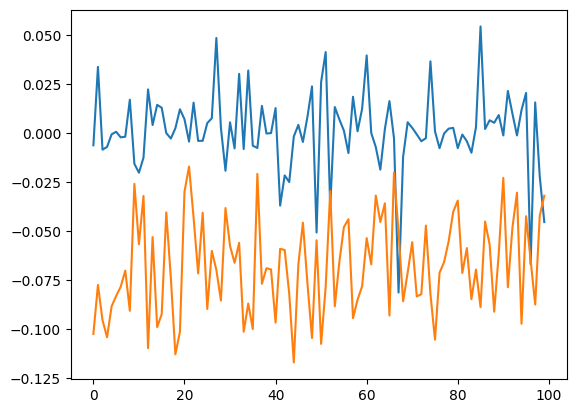

In [142]:
dio, porco = [], []
for n in range(1,101):
    file_path = f'./data/test/raw/DSE-DACE100/workdir.{n}'
    L, D = get_lift_drag_from_file(file_path)
    CL, CD = 2*L, 2*D
    cl_true, cd_true = read_Cs(file_path)
    dio.append(float(cl_true) - CL)
    porco.append(float(cd_true) - CD)
    #print(cl_true, CL, cd_true, CD)
plt.plot(dio)
plt.plot(porco)

In [ ]:
for n in range(1,30):
    file_path = f'./data/test/raw/DSE-DACE100/workdir.{n}'
    L, D = get_lift_drag_from_file(file_path)
    CL, CD = 2*L, 2*D
    cl_true, cd_true = read_Cs(file_path)
    print(cl_true, CL, cd_true, CD)

-0.198834 tensor(0.2382, dtype=torch.float64) 2.51714 tensor(0.6216, dtype=torch.float64)
0.0215903 tensor(0.0697, dtype=torch.float64) 1.628 tensor(2.3339, dtype=torch.float64)
-0.412129 tensor(0.4898, dtype=torch.float64) 2.91775 tensor(0.7013, dtype=torch.float64)
-0.205081 tensor(0.2875, dtype=torch.float64) 2.17047 tensor(1.1628, dtype=torch.float64)
-0.323244 tensor(0.3608, dtype=torch.float64) 2.93172 tensor(-0.3292, dtype=torch.float64)
-0.047391 tensor(0.1146, dtype=torch.float64) 1.8581 tensor(1.3976, dtype=torch.float64)
0.0392204 tensor(0.0052, dtype=torch.float64) 1.96366 tensor(-0.0192, dtype=torch.float64)
-0.00559645 tensor(0.0123, dtype=torch.float64) 2.20972 tensor(-0.2242, dtype=torch.float64)
-0.248751 tensor(0.3246, dtype=torch.float64) 2.21693 tensor(-0.3648, dtype=torch.float64)
-0.0682526 tensor(0.1140, dtype=torch.float64) 0.925116 tensor(2.3580, dtype=torch.float64)
-0.110108 tensor(0.0604, dtype=torch.float64) 1.33537 tensor(1.9366, dtype=torch.float64)
-0.25

In [ ]:
for n in range(1,30):
    file_path = f'./data/test/raw/DSE-DACE100/workdir.{n}'
    L, D = get_lift_drag_from_file(file_path)
    CL, CD = 2*L, 2*D
    cl_true, cd_true = read_Cs(file_path)
    print(cl_true, CL, cd_true, CD)

-0.198834 tensor(0.0367, dtype=torch.float64) 2.51714 tensor(2.7818, dtype=torch.float64)
0.0215903 tensor(0.0526, dtype=torch.float64) 1.628 tensor(3.4805, dtype=torch.float64)
-0.412129 tensor(0.0730, dtype=torch.float64) 2.91775 tensor(3.1936, dtype=torch.float64)
-0.205081 tensor(0.0832, dtype=torch.float64) 2.17047 tensor(2.9499, dtype=torch.float64)
-0.323244 tensor(0.0310, dtype=torch.float64) 2.93172 tensor(2.3112, dtype=torch.float64)
-0.047391 tensor(0.0658, dtype=torch.float64) 1.8581 tensor(2.8674, dtype=torch.float64)
0.0392204 tensor(0.0470, dtype=torch.float64) 1.96366 tensor(1.7318, dtype=torch.float64)
-0.00559645 tensor(0.0067, dtype=torch.float64) 2.20972 tensor(1.7585, dtype=torch.float64)
-0.248751 tensor(0.0562, dtype=torch.float64) 2.21693 tensor(1.6566, dtype=torch.float64)
-0.0682526 tensor(0.0573, dtype=torch.float64) 0.925116 tensor(2.8472, dtype=torch.float64)
-0.110108 tensor(-0.0258, dtype=torch.float64) 1.33537 tensor(2.8571, dtype=torch.float64)
-0.25949

KeyboardInterrupt: 

In [ ]:
for n in range(1,30):
    file_path = f'./data/test/raw/DSE-DACE100/workdir.{n}'
    L, D = get_lift_drag_from_file(file_path)
    CL, CD = 2*L, 2*D
    cl_true, cd_true = read_Cs(file_path)
    print(cl_true, CL, cd_true, CD)

-0.198834 tensor(0.2092) 2.51714 tensor(-1.7026)
0.0215903 tensor(0.0218) 1.628 tensor(-0.5867)
-0.412129 tensor(0.4299) 2.91775 tensor(-1.9721)
-0.205081 tensor(0.2107) 2.17047 tensor(-1.3002)
-0.323244 tensor(0.3381) 2.93172 tensor(-2.2628)
-0.047391 tensor(0.0510) 1.8581 tensor(-1.0000)
0.0392204 tensor(-0.0412) 1.96366 tensor(-1.4630)
-0.00559645 tensor(0.0057) 2.20972 tensor(-1.6885)
-0.248751 tensor(0.2703) 2.21693 tensor(-1.7399)
-0.0682526 tensor(0.0640) 0.925116 tensor(-0.0264)
-0.110108 tensor(0.0830) 1.33537 tensor(-0.4490)
-0.259496 tensor(0.2620) 0.998244 tensor(-0.0326)
-0.538724 tensor(0.5681) 3.09104 tensor(-2.3236)
0.0136553 tensor(-0.0137) 1.34455 tensor(-0.4616)
-0.214787 tensor(0.2287) 2.97185 tensor(-2.1496)
-0.0891864 tensor(0.1115) 2.24306 tensor(-1.4707)
0.0164895 tensor(-0.0202) 1.18174 tensor(-0.4014)
-0.159095 tensor(0.1766) 1.76445 tensor(-0.8653)
-0.405156 tensor(0.4174) 3.30869 tensor(-2.5828)
-0.342922 tensor(0.3679) 2.55968 tensor(-1.7542)
-0.00526018 te

In [ ]:
def read_Cs(file_path):
    with open(os.path.join(file_path, 'outldm.txt'), 'r') as f:
        cs = f.read().split()[-3:-1]
    return cs

for n in range(1,30):
    file_path = f'./data/test/raw/DSE-DACE100/workdir.{n}'
    L, D = get_lift_drag_from_file(file_path)
    CL, CD = 2*L, 2*D
    cl_true, cd_true = read_Cs(file_path)
    print(cl_true, CL, cd_true, CD)

-0.198834 tensor(0.1938) 2.51714 tensor(-2.6179)
0.0215903 tensor(0.0124) 1.628 tensor(-1.7066)
-0.412129 tensor(0.4037) 2.91775 tensor(-3.0128)
-0.205081 tensor(0.1978) 2.17047 tensor(-2.2740)
-0.323244 tensor(0.3216) 2.93172 tensor(-3.0181)
-0.047391 tensor(0.0466) 1.8581 tensor(-1.9395)
0.0392204 tensor(-0.0425) 1.96366 tensor(-2.0390)
-0.00559645 tensor(0.0055) 2.20972 tensor(-2.2767)
-0.248751 tensor(0.2663) 2.21693 tensor(-2.3029)
-0.0682526 tensor(0.0494) 0.925116 tensor(-0.9521)
-0.110108 tensor(0.0893) 1.33537 tensor(-1.3918)
-0.259496 tensor(0.2411) 0.998244 tensor(-1.0339)
-0.538724 tensor(0.5582) 3.09104 tensor(-3.1998)
0.0136553 tensor(-0.0082) 1.34455 tensor(-1.3974)
-0.214787 tensor(0.2286) 2.97185 tensor(-3.0698)
-0.0891864 tensor(0.1028) 2.24306 tensor(-2.3323)
0.0164895 tensor(-0.0161) 1.18174 tensor(-1.2224)
-0.159095 tensor(0.1563) 1.76445 tensor(-1.8379)
-0.405156 tensor(0.4077) 3.30869 tensor(-3.4210)
-0.342922 tensor(0.3550) 2.55968 tensor(-2.6612)
-0.00526018 te

In [ ]:
def extract_body_faces():
    def order_segments_endpoints_(body_faces):
        """
        Orders the endpoints in place making up the "1d face" such that the first one
        comes first in clockwise order than the second.
        I need it to define the tangent and normal unequivocally
        """
        centroid = body_faces.mean(dim=(0,1))
        angles = torch.arctan2(body_faces[:,:,1]-centroid[1], body_faces[:,:,0]-centroid[0])
        prof_faces_flipped = body_faces.flip(dims=(1,))
        # I want angles[:,0] > angles[:,1] but treating differently the segment for which the atan is discontinuous 
        # mask = angles[:,0]<angles[:,1] & angles[:,0]*angles[:,1]>8 # I want to trat the segment whose endpoints have angles ~+pi and ~-pi separately
        mask = torch.logical_and(angles[:,0]<angles[:,1], angles[:,0]*angles[:,1]>-8)
        body_faces[mask] = prof_faces_flipped[mask]
        # angles[x,0] should be negative and angles[x,1] positive, so if not already the case, flip
        if angles[angles[:,0]*angles[:,1]<-8,0] > 0:
            body_faces[angles[:,0]*angles[:,1]<-8] = body_faces[angles[:,0]*angles[:,1]<-8]
        return body_faces
    patches = parse_boundary()
    # get idx of faces in file faces belonging to the object
    body_faces_idx = list(range(patches['prof_extruded']['startFace'],patches['prof_extruded']['startFace']+patches['prof_extruded']['nFaces']))
    # construct an Nx4 tensor of the indices of the 4 points making up each face
    body_faces_points_idx = torch.tensor([faces[i] for i in body_faces_idx])
    # construct an Nx4x3 tensor with the 3 coordinates (x,y,z) of the 4 verteces making up the N faces
    body_faces = points[body_faces_points_idx]

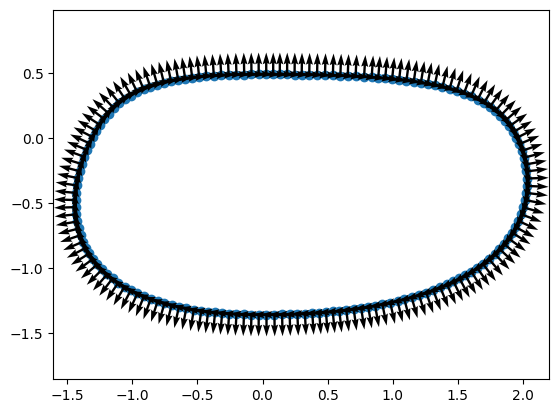

In [ ]:
plt.scatter(body_coords[:,0], body_coords[:,1])
plt.axis('equal')
plt.quiver(body_coords[:,0], body_coords[:,1], normals[:,0], normals[:,1])
plt.quiver(body_coords[:,0], body_coords[:,1], tangents[:,0], tangents[:,1])
plt.show()

tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 

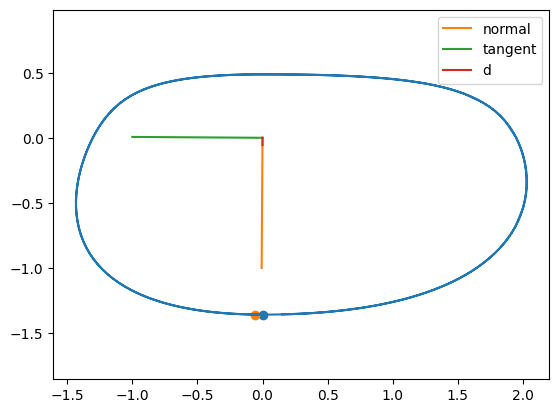

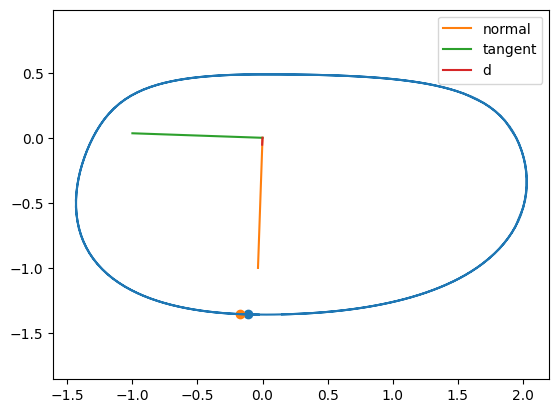

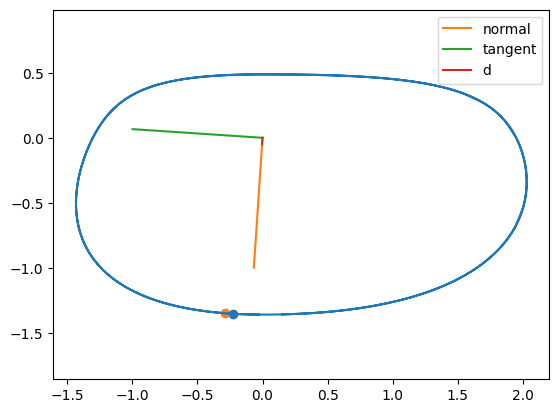

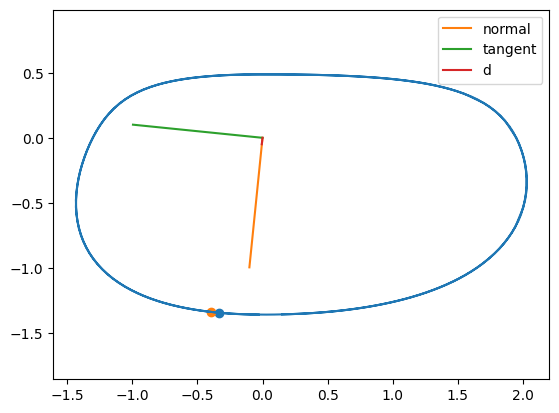

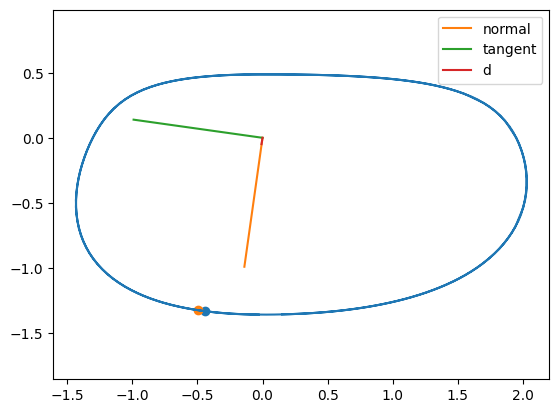

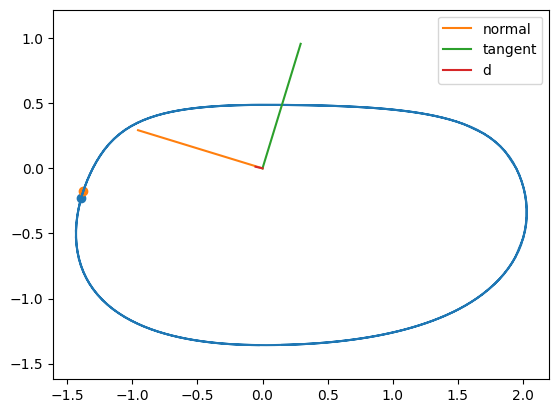

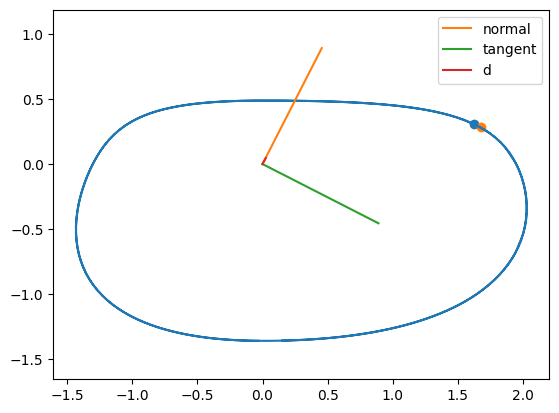

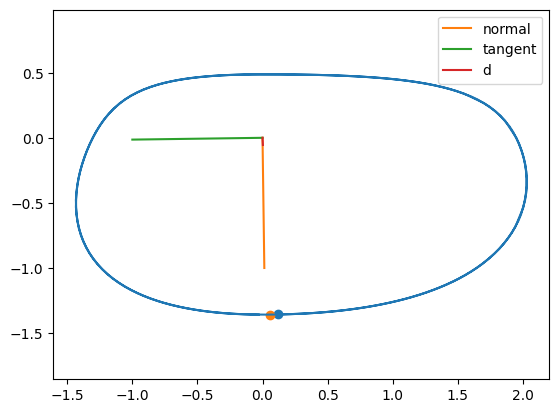

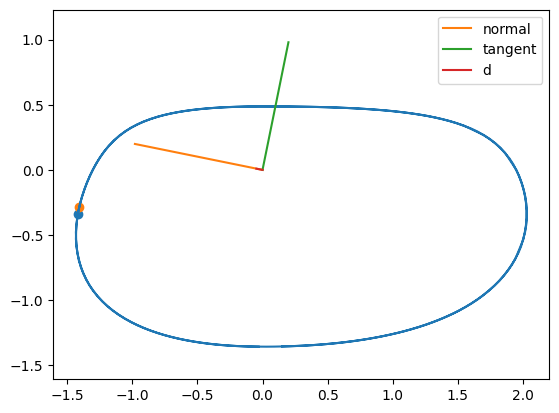

In [ ]:
owners, neighbours, points, faces, node_type_one_hot, body_faces, body_faces_idx = extract_polymesh('./data/test/raw/DSE-DACE100/workdir.2/constant/polyMesh')
velocity, velocity_mean, pressure, pressure_mean, centers, body_coords = extract_fields('./data/test/raw/DSE-DACE100/workdir.2/1000')
def get_d():
    centers_body_faces = body_faces.mean(dim=1)
    centers_cell_body = centers[owners[body_faces_idx]]
    delta = centers_cell_body - centers_body_faces
    return delta

def get_body_velocities_pressures():
    velocities = velocity_mean[owners[body_faces_idx]]
    pressures = pressure_mean[owners[body_faces_idx]].squeeze()   # from (N,1) to (N,)
    return velocities, pressures

def get_tangents_normals():
    angles = torch.arctan2(body_faces[:,0,1]-body_faces[:,1,1], body_faces[:,0,0]-body_faces[:,1,0])
    normals = torch.stack((torch.sin(angles), -torch.cos(angles)), dim=-1)
    tangents = torch.stack((-torch.cos(angles), -torch.sin(angles)), dim=-1)
    return tangents, normals

tangents,normals = get_tangents_normals()
d = get_d()
print(tangents[:,0]*normals[:,1] - tangents[:,1]*normals[:,0])

for n in list(range(5))+[101, 50, 80, 100]:
    plt.plot(body_coords[:,0], body_coords[:,1])
    plt.scatter(body_faces[n,0,0], body_faces[n,0,1])
    plt.scatter(body_faces[n,1,0], body_faces[n,1,1])
    plt.plot([0,normals[n,0]], [0, normals[n,1]], label='normal')
    plt.plot([0,tangents[n,0]], [0, tangents[n,1]], label='tangent')
    plt.plot([0,d[n,0]*3], [0, d[n,1]*3], label='d')
    plt.axis('equal')
    plt.legend()
    plt.show()

In [ ]:
tangents

tensor([[-1.0000,  0.0073],
        [-0.9991,  0.0423],
        [-0.9965,  0.0831],
        [-0.9920,  0.1263],
        [-0.9839,  0.1786],
        [-0.9702,  0.2422],
        [-0.9500,  0.3121],
        [-0.9178,  0.3971],
        [-0.8695,  0.4939],
        [-0.8008,  0.5990],
        [-0.7130,  0.7011],
        [-0.6022,  0.7983],
        [-0.4789,  0.8779],
        [-0.3494,  0.9370],
        [-0.2266,  0.9740],
        [-0.1224,  0.9925],
        [-0.0426,  0.9991],
        [ 0.0203,  0.9998],
        [ 0.0707,  0.9975],
        [ 0.1094,  0.9940],
        [ 0.1353,  0.9908],
        [ 0.1497,  0.9887],
        [ 0.1562,  0.9877],
        [ 0.1709,  0.9853],
        [ 0.2058,  0.9786],
        [ 0.2612,  0.9653],
        [ 0.3405,  0.9402],
        [ 0.4448,  0.8956],
        [ 0.5596,  0.8287],
        [ 0.6185,  0.7858],
        [ 0.6804,  0.7328],
        [ 0.7391,  0.6736],
        [ 0.8335,  0.5525],
        [ 0.8700,  0.4931],
        [ 0.8994,  0.4371],
        [ 0.9432,  0

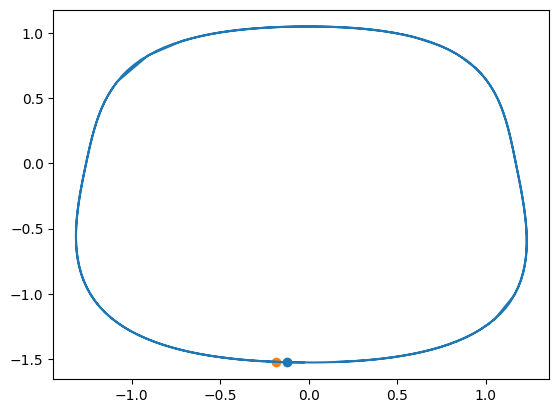

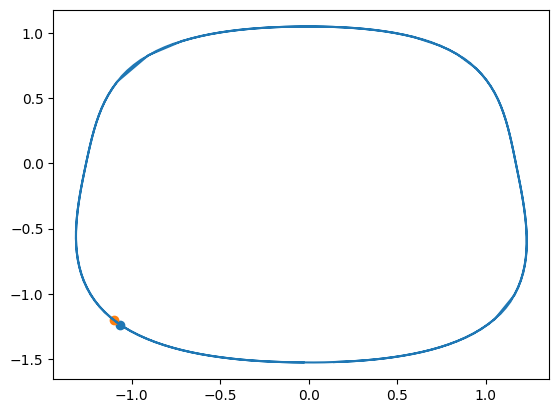

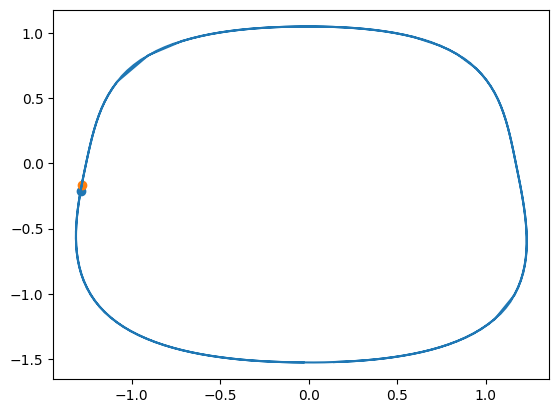

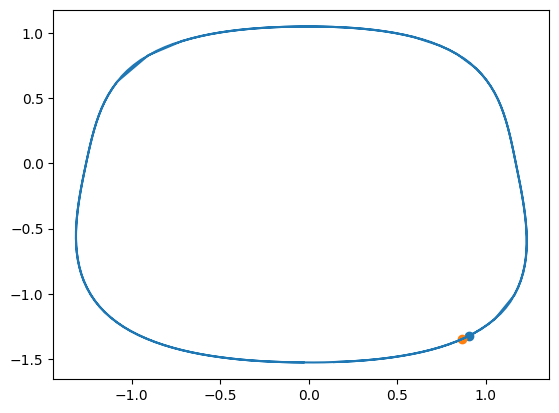

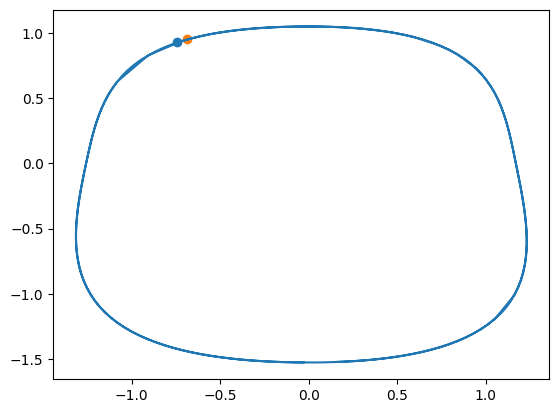

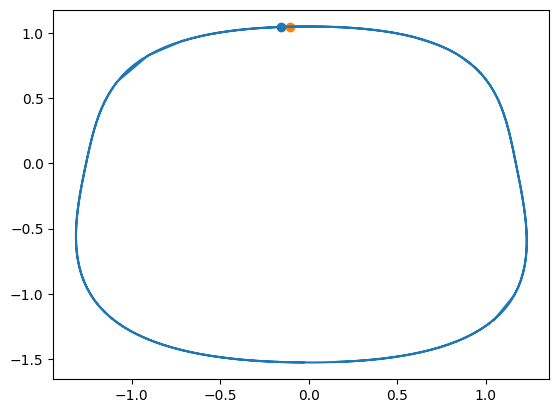

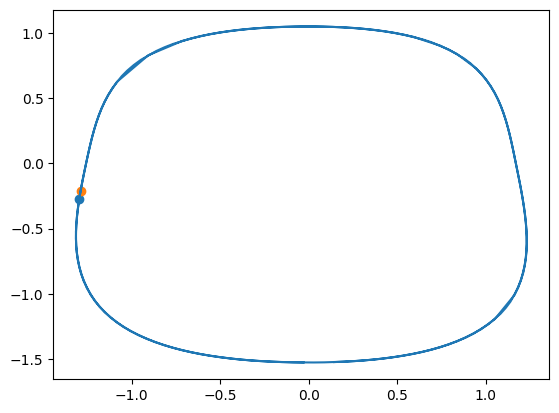

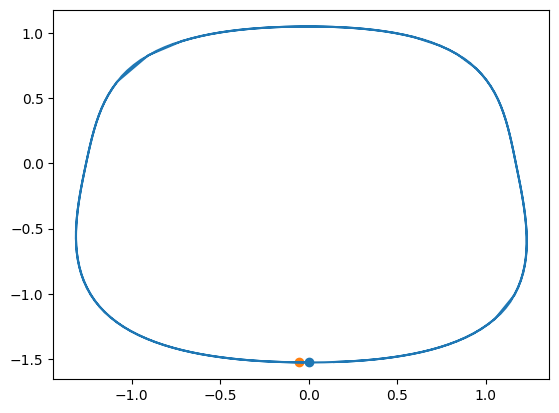

In [ ]:
# check
idx = torch.arange(len(angles))[angles[:,0]*angles[:,1]<-8].item()
for n in [1,10,20,145,111,40, idx,0]:
    plt.plot(body_coords[:,0], body_coords[:,1])
    plt.scatter(ordered_segments[n,0,0], ordered_segments[n,0,1])
    plt.scatter(ordered_segments[n,1,0], ordered_segments[n,1,1])
    plt.show()

In [ ]:
angles = torch.arctan2(ordered_segments[:,0,1]-ordered_segments[:,1,1], ordered_segments[:,0,0]-ordered_segments[:,1,0])
normals = torch.stack((torch.sin(angles), -torch.cos(angles)), dim=-1)
tangents = torch.stack((-torch.cos(angles), -torch.sin(angles)), dim=-1)

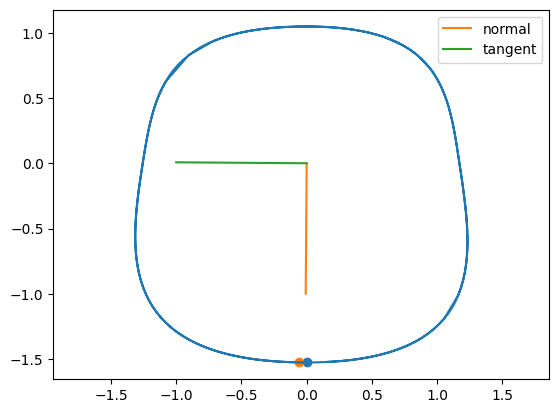

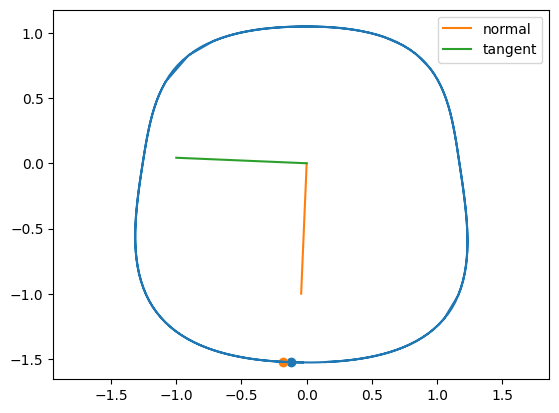

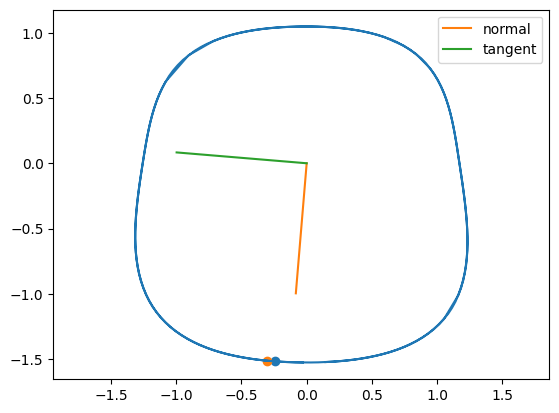

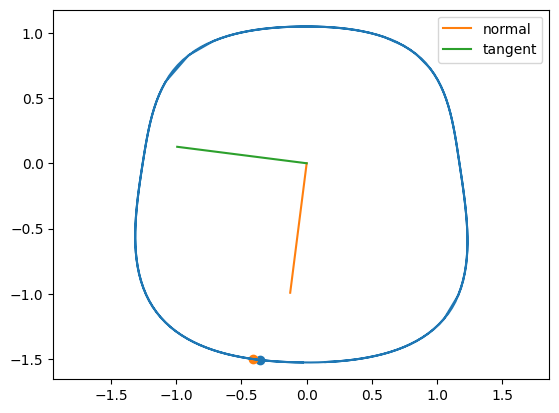

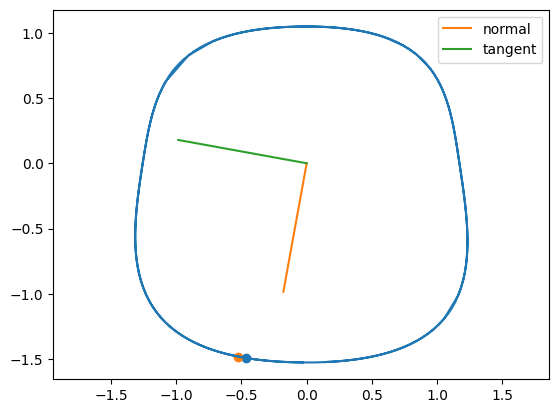

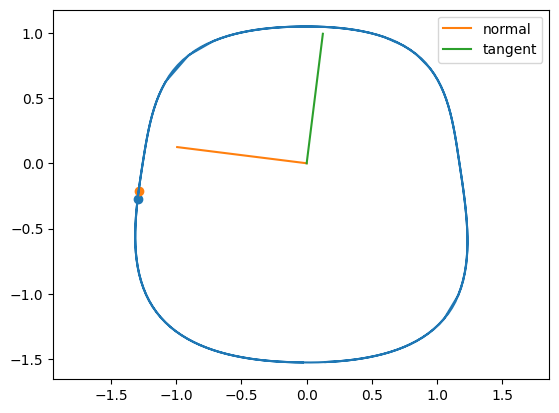

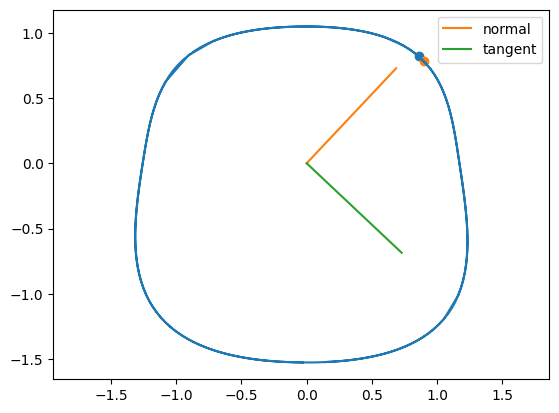

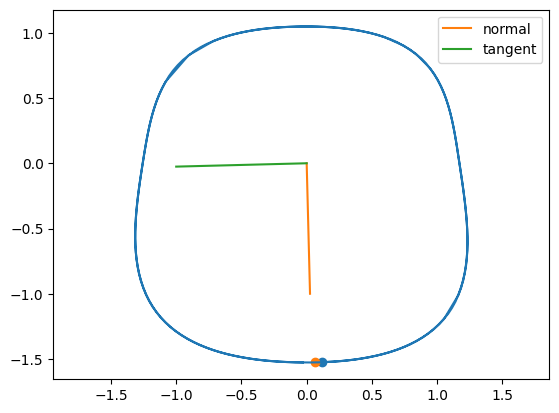

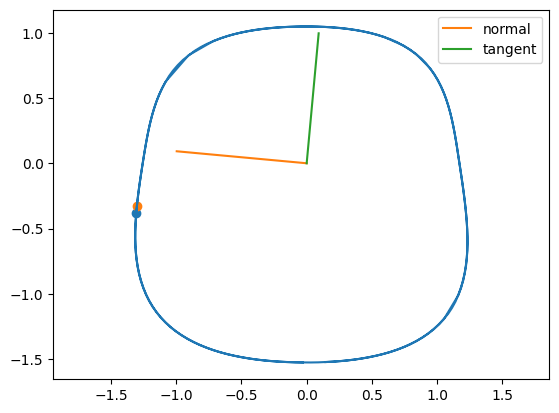

In [ ]:
for n in list(range(5))+[idx, 50, 80, 100]:
    plt.plot(body_coords[:,0], body_coords[:,1])
    plt.scatter(ordered_segments[n,0,0], ordered_segments[n,0,1])
    plt.scatter(ordered_segments[n,1,0], ordered_segments[n,1,1])
    plt.plot([0,normals[n,0]], [0, normals[n,1]], label='normal')
    plt.plot([0,tangents[n,0]], [0, tangents[n,1]], label='tangent')
    plt.axis('equal')
    plt.legend()
    plt.show()

In [ ]:
len(ordered_segments[angles[:,0]<angles[:,1]]), len(ordered_segments[angles[:,0]>angles[:,1]])

(1, 152)

In [ ]:
angles[101], angles[100]

(tensor([-3.1314,  3.1053]), tensor([-3.0425, -3.0874]))

In [ ]:
torch.arange(prof_faces.size(0))[angles[:,0]<angles[:,1]]

tensor([101])

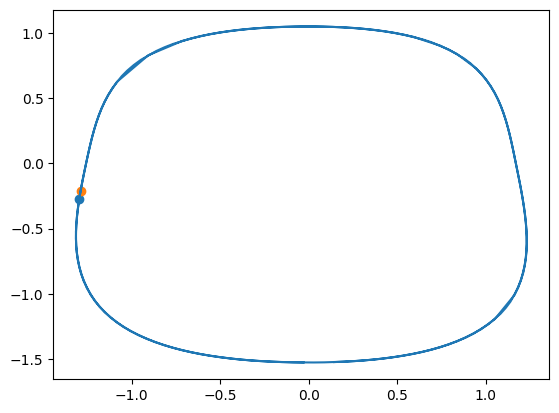

In [ ]:
plt.scatter(prof_faces[101,0,0], prof_faces[101,0,1])
plt.scatter(prof_faces[101,1,0], prof_faces[101,1,1])
plt.plot(body_coords[:,0], body_coords[:,1])

tensor([-1.4813, -1.5202])
tensor([1.6603, 1.6214])


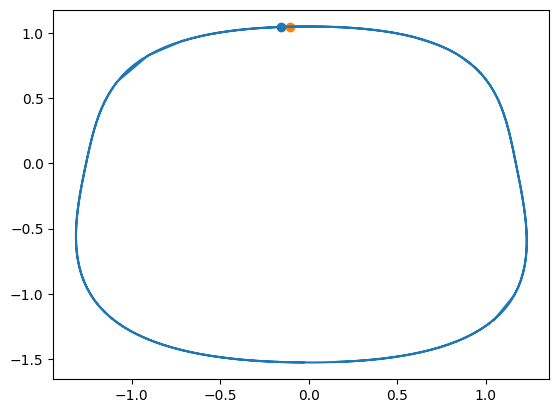

In [ ]:
n = 40
centroid = prof_faces.mean(dim=(0,1))
angles2 = torch.arctan2(prof_faces[:,:,1]-centroid[1], prof_faces[:,:,0]-centroid[0])
angles1 = torch.arctan((prof_faces[:,:,1]-centroid[1]) / (prof_faces[:,:,0]-centroid[0]))
print(angles1[n])
print(angles2[n])
plt.scatter(prof_faces[n,0,0], prof_faces[n,0,1])
plt.scatter(prof_faces[n,1,0], prof_faces[n,1,1])
plt.plot(body_coords[:,0], body_coords[:,1])

In [ ]:
x = torch.tensor(1)
y = torch.tensor(-1)
torch.arctan2(y,x), torch.pi/4

(tensor(-0.7854), 0.7853981633974483)

In [ ]:
# tangent !!!!!!!!!!!!!!!!!!! Needs to go clockwise
def order_segments_endpoints(segments):
    centroid = segments.mean(dim=(0,1))
    p1 = segments[:,0]
    p2 = segments[:,1]
    angles1 = torch.arctan2(p1[:,1]-centroid[1], p1[:,0]-centroid[0])
    angles2 = torch.arctan2(p2[:,1]-centroid[1], p2[:,0]-centroid[0])


clockwise_segment_prof_faces
prof_faces[:,1] - prof_faces[:,0]

tensor([[-0.0565,  0.0004],
        [-0.0646,  0.0027],
        [-0.0592,  0.0049],
        [-0.0513,  0.0065],
        [-0.0609,  0.0111],
        [-0.0509,  0.0127],
        [-0.0503,  0.0165],
        [-0.0499,  0.0216],
        [-0.0491,  0.0279],
        [-0.0401,  0.0300],
        [-0.0375,  0.0369],
        [-0.0305,  0.0404],
        [-0.0247,  0.0453],
        [-0.0210,  0.0564],
        [-0.0124,  0.0534],
        [-0.0071,  0.0574],
        [-0.0021,  0.0501],
        [ 0.0010,  0.0509],
        [ 0.0041,  0.0584],
        [ 0.0061,  0.0557],
        [ 0.0069,  0.0503],
        [ 0.0084,  0.0554],
        [ 0.0092,  0.0581],
        [ 0.0095,  0.0546],
        [ 0.0115,  0.0545],
        [ 0.0147,  0.0543],
        [ 0.0171,  0.0471],
        [ 0.0253,  0.0509],
        [ 0.0286,  0.0424],
        [ 0.0329,  0.0417],
        [ 0.0406,  0.0437],
        [ 0.0405,  0.0369],
        [ 0.0464,  0.0307],
        [ 0.0474,  0.0269],
        [ 0.0488,  0.0237],
        [ 0.0532,  0

In [ ]:
# normal
v = prof_faces[:,0,:] - prof_faces[:,1,:]
n1 = torch.stack((-v[:,1], v[:,0]), dim=-1)
n2 = torch.stack((v[:,1], -v[:,0]))


(tensor([ 0.0565, -0.0004]), tensor([0.0004, 0.0565]))

In [ ]:
body_coords[-1], prof_faces[-1].mean(dim=0)

(tensor([ 0.1444, -1.5234]), tensor([ 0.1444, -1.5234]))

In [ ]:
prof_faces.shape, prof_faces

(torch.Size([153, 2, 2]),
 tensor([[[ 0.0000, -1.5266],
          [-0.0565, -1.5262]],
 
         [[-0.1192, -1.5247],
          [-0.1838, -1.5220]],
 
         [[-0.2443, -1.5182],
          [-0.3035, -1.5133]],
 
         [[-0.3583, -1.5075],
          [-0.4096, -1.5010]],
 
         [[-0.4658, -1.4925],
          [-0.5268, -1.4814]],
 
         [[-0.5847, -1.4689],
          [-0.6356, -1.4562]],
 
         [[-0.6883, -1.4411],
          [-0.7387, -1.4246]],
 
         [[-0.7925, -1.4043],
          [-0.8423, -1.3827]],
 
         [[-0.8911, -1.3586],
          [-0.9401, -1.3307]],
 
         [[-0.9857, -1.3010],
          [-1.0258, -1.2710]],
 
         [[-1.0641, -1.2382],
          [-1.1016, -1.2014]],
 
         [[-1.1361, -1.1620],
          [-1.1666, -1.1215]],
 
         [[-1.1950, -1.0775],
          [-1.2197, -1.0322]],
 
         [[-1.2415, -0.9846],
          [-1.2625, -0.9282]],
 
         [[-1.2782, -0.8753],
          [-1.2906, -0.8219]],
 
         [[-1.3005, -0.7658],

In [ ]:
body_points = prof_faces.reshape(prof_faces.size(0)*2,2)

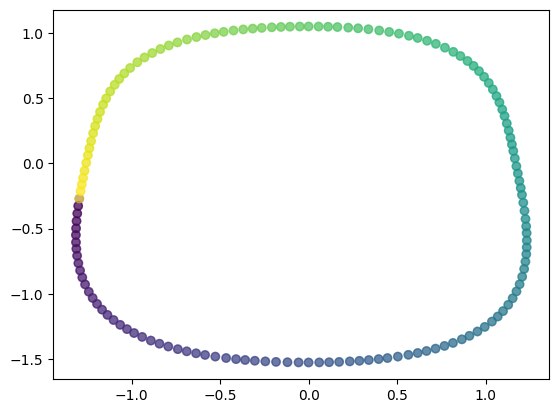

In [ ]:
def get_ordered_body_coords_mine(points):
    centroid = points.mean(dim=0)
    angles = torch.arctan2(points[:,1]-centroid[1], points[:,0]-centroid[0])
    sorted_idx = torch.argsort(angles)
    return sorted_idx, points[sorted_idx]

sorted_idx, _ = get_ordered_body_coords_mine(body_coords)

ordered_prof_faces = prof_faces[sorted_idx]
ordered_body_points = ordered_prof_faces.reshape(ordered_prof_faces.size(0)*2,2)
colors = np.linspace(0,1,ordered_body_points.size(0))
cmap = plt.cm.viridis
plt.scatter(ordered_body_points[:,0], ordered_body_points[:,1], c=cmap(colors), alpha=.5)

In [ ]:
def get_normals(points):
    xpan = np.concatenate([points[0:-1, 0:1], points[1:, 0:1]], axis=1)
    ypan = np.concatenate([points[0:-1, 1:2], points[1:, 1:2]], axis=1)
    dx = np.diff(xpan, axis=1)
    dy = np.diff(ypan, axis=1)
    thpan = np.arctan2(dy, dx)
    nor = np.concatenate([-np.sin(thpan), np.cos(thpan)], axis=1)
    return nor

normals = get_normals(ordered_body_points)
normals[50], ordered_body_points[50]

(array([-0.3526683, -0.9357484], dtype=float32), tensor([-0.7387, -1.4246]))

In [ ]:
du_normal = 